# TSARA, Phase 6 — events

**A walkthrough you can run, change and try to break.** Every number and figure
below is produced by the package from data manufactured inside this notebook,
where every plume the generator injected is known. No real measurement is read,
and nothing needs mounting. Notebook `06b` runs the same stage on the campaign
archive.

---

## How to use this notebook

1. **Run everything once** (*Run All*, about a minute).
2. **Every section stands on its own.** Each opens with a **parameters cell**:
   a short list of CAPITALISED names, each commented with what it controls.
   Change a value, then run that section's cells from the parameters cell down
   to the next heading. Sections share only the two setup cells below.
3. **Every section prints checks.** A line beginning ✔ is a claim about TSARA,
   compared *as it ran* against something written independently in this
   notebook: a loop written from the definition, a closed form, or the
   generator's answer key. The checks are written to hold at *any* parameters.
   If you ever see ✘, you have found an edge case worth understanding or a bug.
4. **"Try it"** notes after each section suggest a change and say what should
   happen. Each prediction was run before this notebook was committed.
5. **Section 8** collects every check into one scoreboard and lists what is
   known to be imperfect.

---

## What this phase delivers

A plume only adds to the air, so an enhancement's readings below its most common
value are plume-free air. Phase 6 measures that air and finds events against it,
per variable, per stretch of record, at every point of the baseline's window ×
quantile sweep and of its own entry × exit thresholds (`METHODS.md` §6.8):

| | Property | Section |
|---|---|---|
| 1 | **Plume-free air is measured, not modelled**: its most common enhancement (the clean level) and 1.4826 × the median distance below it (the clean spread) | §1 |
| 2 | **Described one record at a time**: a stream split at long gaps and where the platform parks or drives, and cut to a maximum length; a gap between readings is a dropout | §2 |
| 3 | **Events by two thresholds**: a run above the exit multiple that reaches the entry multiple, short dips and short holes bridged; chance has a known rate, recorded beside every count | §3 |
| 4 | **The window decides what is a plume**, and a tree links each event to the one holding it at a longer window | §4 |
| 5 | **Scoring is a join** against the answer key | §5 |
| 6 | **A sparse canister takes its events** from a dense analyzer | §6 |
| 7 | **The state and the catalog save and reload exactly** | §7 |

What this phase does **not** do: fit ratios, combine uncertainties or build the
stability cube (Phase 7), or smooth and cluster (Phase 8). Nor does it
integrate plume areas (`METHODS.md` §7).

---

## Vocabulary used throughout

| term | meaning |
|---|---|
| **enhancement** Δ | reading minus its baseline at one window and quantile (Phase 5); a little above zero in clean air, by the clean level (§1), and below zero for a few percent of readings, never clipped |
| **plume** | an enhancement in the air from an emission: what the generator injects and this stage looks for |
| **event** | an interval this stage reported on one variable at one sweep point: what that sweep point sees, not a verdict. A plume, part of one, several merged, or a chance crossing; whether it is a plume is judged across the sweep (Phase 7) |
| **record** | a stretch of one variable's readings, split where two are more than a gap apart or where the platform parks or drives for at least that long, and cut to a maximum length; plume-free air is described per record |
| **clean level** *m* | the most common enhancement of a record at a sweep point: its half-sample mode |
| **clean spread** *s* | 1.4826 × the median distance below the clean level, which for Gaussian noise is its standard deviation (§1 says why). *Not* a measurement uncertainty: it holds the background's wobble at the window's scale |
| ***z*** | a reading's height above clean air, counted in clean spreads: (enhancement − clean level) ÷ clean spread. Clean air sits near 0; the default entry is 3 |
| **entry, exit multiple** | an event holds a reading with *z* ≥ entry and runs while *z* ≥ exit |
| **dropout** | two readings of a record more than 1.5 × its median spacing apart; a hole shorter than `max_bridged_dropout` (5 s) is bridged like a dip, a longer one ends an event |
| **sweep point** | one (window, quantile, entry, exit) combination; every one is computed |
| **trigger** | the variable a sparse one takes its events from |
| **source** | an *emission* source only: a landfill, a gas line |

---
## Setup (run these two cells first)

The first cell is the **toolkit**: imports, the figure style shared by notebooks
01–06, helpers, the **reference implementations** every check compares TSARA
against, and the scoreboard. The second holds the **campaign recipes**, one
function per synthetic campaign, whose keyword arguments are the knobs.

In [1]:
# =============================================================================
# TOOLKIT. Every section needs this cell and nothing else from other sections.
# =============================================================================
import logging
import tempfile
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import norm

from tsara import setup_logging
from tsara.baseline import baseline_state
from tsara.config.analysis import BaselineConfig, EventsConfig
from tsara.config.loader import load_synthetic
from tsara.config.synthetic import SyntheticConfig
from tsara.core.support import CellBounds, stream_cells
from tsara.events import (
    CATALOG_COLUMNS,
    event_catalog,
    event_state,
    event_states,
    expected_chance_rate,
    find_events,
    find_records,
    load_events,
    save_events,
)
from tsara.synthetic import generate
from tsara.synthetic.plumes import GROUND_TRUTH_COLUMNS

SECOND = 1_000_000_000  # TSARA keeps every time as integer nanoseconds
HOUR = 3600 * SECOND
# The shipped example configurations, from the notebook's folder or the repo root.
CONFIGS = next(p for p in (Path("../configs"), Path("examples/configs")) if p.is_dir())

# --- 1. figure style (identical to notebooks 01-05) --------------------------
C1, C2, C3 = "#0072b2", "#e69f00", "#009e73"  # Okabe-Ito blue, amber, green: colour-blind safe
C4 = "#cc79a7"  # Okabe-Ito purple, for a fourth series
INK, INK2, MUTED = "#0b0b0b", "#52514e", "#898781"
GRID, SURFACE = "#e1e0d9", "#fcfcfb"
plt.rcParams.update(
    {
        "figure.facecolor": SURFACE,
        "axes.facecolor": SURFACE,
        "savefig.facecolor": SURFACE,
        "axes.edgecolor": "#c3c2b7",
        "axes.linewidth": 0.8,
        "axes.labelcolor": INK2,
        "axes.titlecolor": INK,
        "axes.titlesize": 11,
        "axes.titleweight": "normal",
        "axes.titlelocation": "left",
        "axes.labelsize": 9.5,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "xtick.color": MUTED,
        "ytick.color": MUTED,
        "xtick.labelsize": 8.5,
        "ytick.labelsize": 8.5,
        "grid.color": GRID,
        "grid.linewidth": 0.7,
        "grid.linestyle": "-",
        "legend.frameon": False,
        "legend.fontsize": 9,
        "font.size": 9.5,
        "lines.linewidth": 1.4,
        "figure.dpi": 110,
    }
)


def finish(
    ax, title=None, sub=None, ylab=None, xlab=None, legend=False, grid_axis="y", loc="upper right"
):
    """Apply the shared chrome: left-aligned title, muted subtitle, hairline grid."""
    if title:
        ax.set_title(title, pad=19 if sub else 8)
    if sub:
        ax.text(0, 1.025, sub, transform=ax.transAxes, fontsize=8.8, color=MUTED, va="bottom")
    if ylab:
        ax.set_ylabel(ylab)
    if xlab:
        ax.set_xlabel(xlab)
    if grid_axis:
        ax.grid(True, axis=grid_axis, alpha=0.9)
    ax.set_axisbelow(True)
    if legend:
        ax.legend(loc=loc)


def hhmm(ax, fmt="%H:%M"):
    """Label the x axis as clock time; the date belongs in the title."""
    ax.xaxis.set_major_formatter(mdates.DateFormatter(fmt))


def break_gaps(clock, values, tolerance=5.0):
    """Insert a NaN wherever the clock jumps, so matplotlib draws no line across a gap.

    A plotted line is a straight segment between neighbouring points, so a hole
    in a record would otherwise render as a smooth ramp across it: exactly the
    interpolation TSARA refuses to perform on a gas.
    """
    clock, values = np.asarray(clock), np.asarray(values, dtype=float)
    steps = np.diff(clock).astype("timedelta64[ms]").astype(float)
    gaps = np.where(steps > tolerance * np.median(steps))[0]
    if gaps.size == 0:
        return clock, values
    return np.insert(clock, gaps + 1, clock[gaps]), np.insert(values, gaps + 1, np.nan)


def shade_events(ax, cells, membership, color=C2, alpha=0.25):
    """Shade each event's interval, first cell start to last cell stop."""
    for k in np.unique(membership[membership >= 0]):
        rows = np.flatnonzero(membership == k)
        ax.axvspan(
            pd.Timestamp(int(cells.start_ns[rows[0]])),
            pd.Timestamp(int(cells.stop_ns[rows[-1]])),
            color=color,
            alpha=alpha,
            lw=0,
        )


# --- 2. streams and arrays ----------------------------------------------------
def same(a, b):
    """Equal arrays, blanks in the same places counting as equal."""
    a, b = np.asarray(a), np.asarray(b)
    if a.dtype.kind in "fc" or b.dtype.kind in "fc":
        return a.shape == b.shape and bool(np.array_equal(a, b, equal_nan=True))
    return bool(np.array_equal(a, b))


def measured(stream):
    """Drop the generator's answer-key columns (`truth_*`), keeping what an instrument reports."""
    return stream.drop_vars([v for v in stream.data_vars if str(v).startswith("truth_")])


def sweep(windows=("2min", "10min", "60min"), quantiles=(0.05,), **more):
    """Return a BaselineConfig for a sweep."""
    return BaselineConfig.model_validate(
        {"windows": list(windows), "quantiles": list(quantiles), **more}
    )


def thresholds(enter=(3.0,), exit_=(1.0,), **more):
    """Return an EventsConfig: entry and exit multiples plus any other setting."""
    return EventsConfig.model_validate(
        {"enter_multiple": list(enter), "exit_multiple": list(exit_), **more}
    )


# --- 3. reference implementations --------------------------------------------
# Written from the definitions in METHODS §6.8, deliberately slow and plain. They
# share no code with TSARA: no vectorized search, no sort carried between steps.
# If TSARA and these agree, it is because both compute the definition.


def reference_half_sample_mode(values):
    """Bickel and Fruhwirth (2006), one interval at a time.

    Sort; keep the shortest interval holding ceil(n/2) of the values (the earliest
    on a tie); repeat until three or fewer remain; of three, the mean of the closer
    pair, or the middle one when the gaps are equal; of two, their mean.
    """
    x = sorted(v for v in values if np.isfinite(v))
    while len(x) > 3:
        half = -(-len(x) // 2)
        best, width = 0, np.inf
        for j in range(len(x) - half + 1):
            if x[j + half - 1] - x[j] < width:
                best, width = j, x[j + half - 1] - x[j]
        x = x[best : best + half]
    if len(x) < 3:
        return float(np.mean(x))
    if x[1] - x[0] < x[2] - x[1]:
        return (x[0] + x[1]) / 2
    if x[1] - x[0] > x[2] - x[1]:
        return (x[1] + x[2]) / 2
    return x[1]


def reference_clean(values):
    """Return the clean level and spread of one record at one sweep point, by definition."""
    level = reference_half_sample_mode(values)
    below = [level - v for v in values if np.isfinite(v) and v < level]
    return level, 1.4826 * float(np.median(below))


def shortest_half_midpoint(values):
    """Return the midpoint of the shortest half: the estimator withdrawn on 2026-09-29."""
    x = np.sort(np.asarray(values)[np.isfinite(values)])
    half = (x.size + 1) // 2
    start = int(np.argmin(x[half - 1 :] - x[: x.size - half + 1]))
    return float((x[start] + x[start + half - 1]) / 2)


def reference_events(z, cells, dropout_before, record, enter, exit_, gap_ns, hole_ns):
    """Events one reading at a time, from METHODS §6.8's paragraph.

    Walk the finite readings in order. A run continues while z >= exit; a record
    change, a blank reading, or a dropout whose hole (the previous reading's cell
    stop to this one's cell start, zero where cells overlap) is not shorter than
    `hole_ns` ends it; a dip below exit is bridged when the time from the last run
    reading's cell stop to the next above-exit reading's cell start is shorter than
    the gap (zero where cells overlap); a run that ever reaches entry is an event.
    Returns each reading's event number, -1 for none.
    """
    membership = np.full(len(z), -1)
    events, current, dip, previous = [], [], [], None

    def close():
        if current and max(z[i] for i in current) >= enter:
            events.append(list(current))

    for i in range(len(z)):
        if record[i] < 0:
            continue
        hole = 0 if previous is None else max(cells.start_ns[i] - cells.stop_ns[previous], 0)
        broken = (
            previous is None
            or record[i] != record[previous]
            or (dropout_before[i] and hole >= hole_ns)
            or np.isnan(z[i])
            or np.isnan(z[previous])
        )
        previous = i
        if broken:
            close()
            current, dip = [], []
        if np.isnan(z[i]):
            continue
        if z[i] >= exit_:
            if current and dip and max(cells.start_ns[i] - cells.stop_ns[current[-1]], 0) >= gap_ns:
                close()
                current, dip = [], []
            current = current + dip + [i]
            dip = []
        elif current:
            dip.append(i)
    close()
    for number, rows in enumerate(events):
        membership[rows] = number
    return membership


def reference_records(midpoints_ns, finite, gap_ns, max_ns, parked=None):
    """Find records one reading at a time, from METHODS §6.8, part edges as exact fractions.

    A piece ends where two consecutive finite readings are more than the gap apart.
    Where it is known whether the platform was parked, a piece also ends at both
    edges of every parked stretch lasting at least the gap: a stretch lasts from its
    first finite reading's midpoint to the next stretch's first, or to its own last
    at the end; a moving stretch never splits. A piece spanning more than the
    maximum is cut into n equal parts, n the fewest that keep each part no longer
    than the maximum; a reading goes to the part its midpoint falls in, the last
    reading to the last part. Empty parts are dropped.
    """
    from fractions import Fraction

    kept = [i for i in range(len(midpoints_ns)) if finite[i]]
    edges = set()  # positions in `kept` where a new piece starts
    if parked is not None:
        firsts = [k for k in range(len(kept)) if k == 0 or parked[kept[k]] != parked[kept[k - 1]]]
        for j, first in enumerate(firsts):
            last = firsts[j + 1] if j + 1 < len(firsts) else len(kept) - 1
            lasting = int(midpoints_ns[kept[last]]) - int(midpoints_ns[kept[first]]) >= gap_ns
            if parked[kept[first]] and lasting:
                edges.add(first)
                if j + 1 < len(firsts):
                    edges.add(firsts[j + 1])
    pieces = []
    for k, i in enumerate(kept):
        joined = pieces and int(midpoints_ns[i]) - int(midpoints_ns[pieces[-1][-1]]) <= gap_ns
        if joined and k not in edges:
            pieces[-1].append(i)
        else:
            pieces.append([i])
    out, record = np.full(len(midpoints_ns), -1), 0
    for piece in pieces:
        first = int(midpoints_ns[piece[0]])
        span = int(midpoints_ns[piece[-1]]) - first
        n = 1
        while Fraction(span, n) > max_ns:
            n += 1
        parts = {}
        for i in piece:
            k = min(int(Fraction(int(midpoints_ns[i]) - first) * n / span) if span else 0, n - 1)
            parts.setdefault(k, len(parts))
            out[i] = record + parts[k]
        record += len(parts)
    return out


def chance_rate(enter, exit_):
    """Events per reading on independent Gaussian readings: the closed form, written out.

    A reading opens a run above exit with probability (1 - p_x) p_x; the run is
    geometric; each reading in it reaches entry with probability p_e / p_x.
    """
    p_x, p_e = norm.sf(exit_), norm.sf(enter)
    return (1 - p_x) * (p_x - (1 - p_x) * (p_x - p_e) / (1 - p_x + p_e))


# --- 4. the scoreboard -------------------------------------------------------
CHECKS = {}  # claim -> (held?, detail); section 9 prints them all


def start_section(tag):
    """Forget a section's earlier checks, so re-running it replaces rather than piles up."""
    for claim in [c for c in CHECKS if c.startswith(tag + " ")]:
        del CHECKS[claim]


def check(claim, holds, detail=""):
    """Record one claim about TSARA and print whether it held just now."""
    CHECKS[claim] = (bool(holds), detail)
    mark = "✔" if holds else "✘ DOES NOT HOLD:"
    print(f"  {mark} {claim}" + (f"   [{detail}]" if detail else ""))


# --- 5. logging, and a scratch directory --------------------------------------
_work = tempfile.TemporaryDirectory()
WORK = Path(_work.name)  # the bundle section writes here


def scrub_work_dir(record):
    """Show the scratch directory as <work> in TSARA's log messages."""
    if isinstance(record.msg, str):
        record.msg = record.msg.replace(str(WORK), "<work>")
    if isinstance(record.args, tuple):
        record.args = tuple(
            str(a).replace(str(WORK), "<work>") if str(WORK) in str(a) else a for a in record.args
        )
    return True


for handler in setup_logging(logging.WARNING).handlers:
    handler.addFilter(scrub_work_dir)

print("toolkit ready")

toolkit ready


In [2]:
# =============================================================================
# CAMPAIGN RECIPES. Each builds one synthetic campaign with the generator from
# notebook 01, which records the truth it used: the plume-free background under
# every reading and every plume it injected (the answer key). Each keyword is a
# knob; its default is what the section introducing the campaign uses.
# =============================================================================


def _field(offset, units="ppb", **background):
    """Return one atmosphere field: a gas at plume-free level `offset`, plus optional terms."""
    return {
        "role": "gas",
        "units": units,
        "background": {"kind": "parametric", "offset": offset, **background},
    }


def _measure(noise, name=None):
    """Return how an instrument measures a field: its 1-sigma noise, and its own name."""
    spec = {"uncertainty": {"random": {"absolute": noise}}}
    if name:
        spec["name"] = name
    return spec


def landfill_campaign(
    *,
    seed=5,
    duration="6h",
    noise_ppb=0.7,
    landfill_per_hour=0.6,
    landfill_sigma="8min",
    landfill_median_ppb=60.0,
    blips_per_hour=10.0,
    blip_median_ppb=120.0,
    random_walk_ppb_per_day=0.0,
    cycle_ppb=0.0,
    cycle_period="24h",
):
    """Build METHODS §6.1's worked case: broad landfill plumes with short gas blips on top.

    One methane field at 1900 ppb seen by one 1 s analyzer (`analyzer`) with
    `noise_ppb` of white noise. Two emitters: a landfill whose plumes last tens
    of minutes, and a gas line whose blips last seconds (EMG, 6 s / 12 s).
    `cycle_ppb` adds a sinusoidal background of that amplitude and period, phased
    so that a daily one is falling steeply through the record, as a morning's
    boundary layer mixes out the night's air.
    """
    sources = {}
    if landfill_per_hour:
        sources["landfill"] = {
            "rate_per_hour": landfill_per_hour,
            "reference_species": "ch4",
            "shape": {"kind": "gaussian", "sigma": landfill_sigma},
            "amplitude": {"kind": "lognormal", "median": landfill_median_ppb, "sigma_log": 0.3},
        }
    if blips_per_hour:
        sources["gas_line"] = {
            "rate_per_hour": blips_per_hour,
            "reference_species": "ch4",
            "shape": {"kind": "emg", "sigma": "6s", "tau": "12s"},
            "amplitude": {"kind": "lognormal", "median": blip_median_ppb, "sigma_log": 0.4},
        }
    background = {"random_walk_std": random_walk_ppb_per_day} if random_walk_ppb_per_day else {}
    if cycle_ppb:
        background.update(
            diurnal_amplitude=cycle_ppb, diurnal_period=cycle_period, diurnal_phase_hours=19.0
        )
    description = {
        "name": "landfill_demo",
        "seed": seed,
        "start": "2026-06-15T10:00:00Z",
        "duration": duration,
        "platform": {"kind": "stationary", "latitude": 40.77, "longitude": -111.89},
        "atmosphere": {
            "truth_resolution": "1s",
            "fields": {"ch4": _field(1900.0, **background)},
            "sources": sources,
        },
        "instruments": {
            "analyzer": {"native_rate": "1s", "measures": {"ch4": _measure(noise_ppb)}}
        },
    }
    return generate(SyntheticConfig.model_validate(description))


def weak_plume_campaign(*, seed=3, duration="3h", plumes_per_hour=3.0, median_ppb=3.2):
    """Build a quiet record with a few weak plumes, each a Gaussian of sigma 40 s.

    One methane field at 1900 ppb, one 1 s analyzer with 0.7 ppb of noise. The
    plumes' peaks are lognormal around `median_ppb`, a few clean spreads high.
    """
    description = {
        "name": "weak_plumes",
        "seed": seed,
        "start": "2026-06-15T10:00:00Z",
        "duration": duration,
        "platform": {"kind": "stationary", "latitude": 40.77, "longitude": -111.89},
        "atmosphere": {
            "truth_resolution": "1s",
            "fields": {"ch4": _field(1900.0)},
            "sources": {
                "weak": {
                    "rate_per_hour": plumes_per_hour,
                    "reference_species": "ch4",
                    "shape": {"kind": "gaussian", "sigma": "40s"},
                    "amplitude": {"kind": "lognormal", "median": median_ppb, "sigma_log": 0.15},
                }
            },
        },
        "instruments": {"analyzer": {"native_rate": "1s", "measures": {"ch4": _measure(0.7)}}},
    }
    return generate(SyntheticConfig.model_validate(description))


def canister_campaign(*, seed=21, duration="6h", fill_every="300s", plumes_per_hour=3.0):
    """Build a whole-air canister sampler beside a dense benzene analyzer.

    `ptr`  measures benzene every second with 0.02 ppb of noise.
    `iwas` measures benzene in canisters, each the mean over a 15 s fill,
           roughly every `fill_every`.
    A refinery's plumes (Gaussian, 3 min) cross both.
    """
    cadence_s = pd.Timedelta(fill_every).total_seconds()
    description = {
        "name": "canister_demo",
        "seed": seed,
        "start": "2026-06-16T15:00:00Z",
        "duration": duration,
        "platform": {"kind": "stationary", "latitude": 40.77, "longitude": -111.89},
        "atmosphere": {
            "fields": {"benzene": _field(0.5)},
            "sources": {
                "refinery": {
                    "rate_per_hour": plumes_per_hour,
                    "reference_species": "benzene",
                    "shape": {"kind": "gaussian", "sigma": "3min"},
                    "amplitude": {"kind": "lognormal", "median": 1.5, "sigma_log": 0.5},
                }
            },
        },
        "instruments": {
            "ptr": {"native_rate": "1s", "measures": {"benzene": _measure(0.02)}},
            "iwas": {
                "native_rate": fill_every,
                "timestamp_jitter": f"{min(60.0, 0.45 * cadence_s):g}s",
                "support": {"method": "mean", "width": "15s"},
                "measures": {"benzene": _measure(0.01, name="benzene_can")},
            },
        },
    }
    return generate(SyntheticConfig.model_validate(description))


print("recipes ready")

recipes ready


---
## 1. What plume-free air looks like, measured

**The question.** An event is an enhancement standing out from plume-free air,
so plume-free air has to be described first: where it sits and how much it
wobbles. The figure below builds the description in three steps.

1. **The baseline runs along the bottom of the clean air, not through it.**
   Phase 5's baseline is a low quantile of each window (here the 5th
   percentile), so it sits below the air's middle, by about 1.6 noise σ for a
   5th percentile of Gaussian noise.
2. **Subtract it, and clean air becomes a band around a small positive value.**
   That value is the **clean level** *m*, the enhancement's most common value
   (its half-sample mode, `half_sample_mode` in `src/tsara/events/clean.py`).
   Plumes only add, so the readings below *m* are plume-free air, and the
   **clean spread** *s* is read off that lower side alone: 1.4826 × the median
   distance below *m* (`describe_clean_air`, same file).
3. **z is the ruler**: a reading's height above clean air, counted in clean
   spreads. Subtract the clean level from its enhancement and divide by the
   clean spread. At the defaults *m* = 1.16 and *s* = 0.75 ppb, so a reading
   3.4 ppb above its baseline has *z* = (3.4 − 1.16) / 0.75 = 3: the dashed line
   in the figure, the default entry.

**Why 1.4826.** The median distance from the centre is a robust width: half the
readings lie closer than it and half farther, and a few plumes cannot pull it
far. For Gaussian noise, half the readings lie within 0.6745 σ of the centre
(the normal distribution puts 75 % of its mass below +0.6745 σ), so
σ = median distance / 0.6745 = 1.4826 × median distance. The constant puts *s*
on a standard deviation's ruler, so *z* = 3 means what 3σ means: 0.13 % of clean
readings reach it. Measured below the centre only, the median distance of
symmetric noise is the same 0.6745 σ, which is why the lower side alone is
enough.

The campaign is `METHODS.md` §6.1's landfill with gas blips, where 40–50 % of
readings sit in a plume. The generator knows which readings are truly
plume-free, so the check is direct: *m* and *s* against the median and
1.4826 × the median distance of the enhancement over the readings whose true
plume is under 0.1 σ.

In [3]:
# ---- PARAMETERS (section 1) --------------------------------------------------
WINDOW = "10min"  # the baseline window whose enhancement is described
QUANTILE = 0.05  # the baseline's quantile
LANDFILL_PER_HOUR = 0.6  # broad landfill plumes an hour (sigma 8 min)
BLIPS_PER_HOUR = 10.0  # short gas blips an hour
CYCLE_PPB = 0.0  # amplitude of a sinusoidal background cycle (0: none)
CYCLE_PERIOD = "24h"  # its period
SEED = 5
ZOOM_START, ZOOM_MINUTES = "14:58", 45  # the stretch drawn in panels 1 and 2

In [4]:
start_section("§1")
campaign = landfill_campaign(
    seed=SEED,
    landfill_per_hour=LANDFILL_PER_HOUR,
    blips_per_hour=BLIPS_PER_HOUR,
    cycle_ppb=CYCLE_PPB,
    cycle_period=CYCLE_PERIOD,
)
stream = campaign.observable("analyzer")  # what the instrument reported, no truth
state = baseline_state(
    stream, instrument="analyzer", baseline=sweep(windows=(WINDOW,), quantiles=(QUANTILE,))
)
found = event_state(state, instrument="analyzer", events=thresholds())
delta = state["enhancement_ch4"].values[:, 0, 0]
level = float(found["clean_level_ch4"].values[0, 0, 0])
spread = float(found["clean_spread_ch4"].values[0, 0, 0])

# The truth: the enhancement over the readings the generator says are plume-free.
sigma = 0.7
true_plume = campaign.streams["analyzer"]["truth_enhancement_ch4"].values
clean = (true_plume < 0.1 * sigma) & np.isfinite(delta)
true_level = float(np.median(delta[clean]))
true_spread = 1.4826 * float(np.median(np.abs(delta[clean] - true_level)))
by_hand_level, by_hand_spread = reference_clean(list(delta))
withdrawn = shortest_half_midpoint(delta)
z = (delta - level) / spread

in_plume = np.mean(true_plume > 3 * sigma)
print(f"readings: {delta.size}, of which in a plume above 3 sigma: {in_plume:.0%}")
print(f"records: {int(found['record_ch4'].max()) + 1}")
print(f"{'':30s} {'level (ppb)':>12s} {'spread (ppb)':>13s}")
print(f"{'TSARA':30s} {level:12.3f} {spread:13.3f}")
print(f"{'the definition, by hand':30s} {by_hand_level:12.3f} {by_hand_spread:13.3f}")
print(f"{'truth (plume-free readings)':30s} {true_level:12.3f} {true_spread:13.3f}")
print(
    f"error in true spreads: TSARA {(level - true_level) / true_spread:+.2f}; "
    f"midpoint of the shortest half (withdrawn) {(withdrawn - true_level) / true_spread:+.2f}"
)
print(
    f"plume-free readings at or above entry (z >= 3): {np.mean(z[clean] >= 3):.2%}, "
    f"against {norm.sf(3):.2%} for Gaussian noise described exactly"
)
check("§1 the clean level is the half-sample mode, as the paper defines it", level == by_hand_level)
check("§1 the clean spread is 1.4826 x the median distance below it", spread == by_hand_spread)
check(
    "§1 z is (enhancement - clean level) / clean spread, reading by reading",
    same(found["z_ch4"].values[:, 0, 0], z),
)
if not CYCLE_PPB:  # a background cycling at the window's scale is a different question (Try it)
    check(
        "§1 the clean level lies within one true spread of truly plume-free air",
        abs(level - true_level) < true_spread,
        f"{(level - true_level) / true_spread:+.2f} true spreads",
    )
    check(
        "§1 the clean spread is within a factor of two of the true one",
        0.5 < spread / true_spread < 2.0,
        f"{spread / true_spread:.2f}",
    )

readings: 21600, of which in a plume above 3 sigma: 41%
records: 1
                                level (ppb)  spread (ppb)
TSARA                                 1.160         0.745
the definition, by hand               1.160         0.745
truth (plume-free readings)           1.060         0.695
error in true spreads: TSARA +0.14; midpoint of the shortest half (withdrawn) +0.06
plume-free readings at or above entry (z >= 3): 0.04%, against 0.13% for Gaussian noise described exactly
  ✔ §1 the clean level is the half-sample mode, as the paper defines it
  ✔ §1 the clean spread is 1.4826 x the median distance below it
  ✔ §1 z is (enhancement - clean level) / clean spread, reading by reading
  ✔ §1 the clean level lies within one true spread of truly plume-free air   [+0.14 true spreads]
  ✔ §1 the clean spread is within a factor of two of the true one   [1.07]


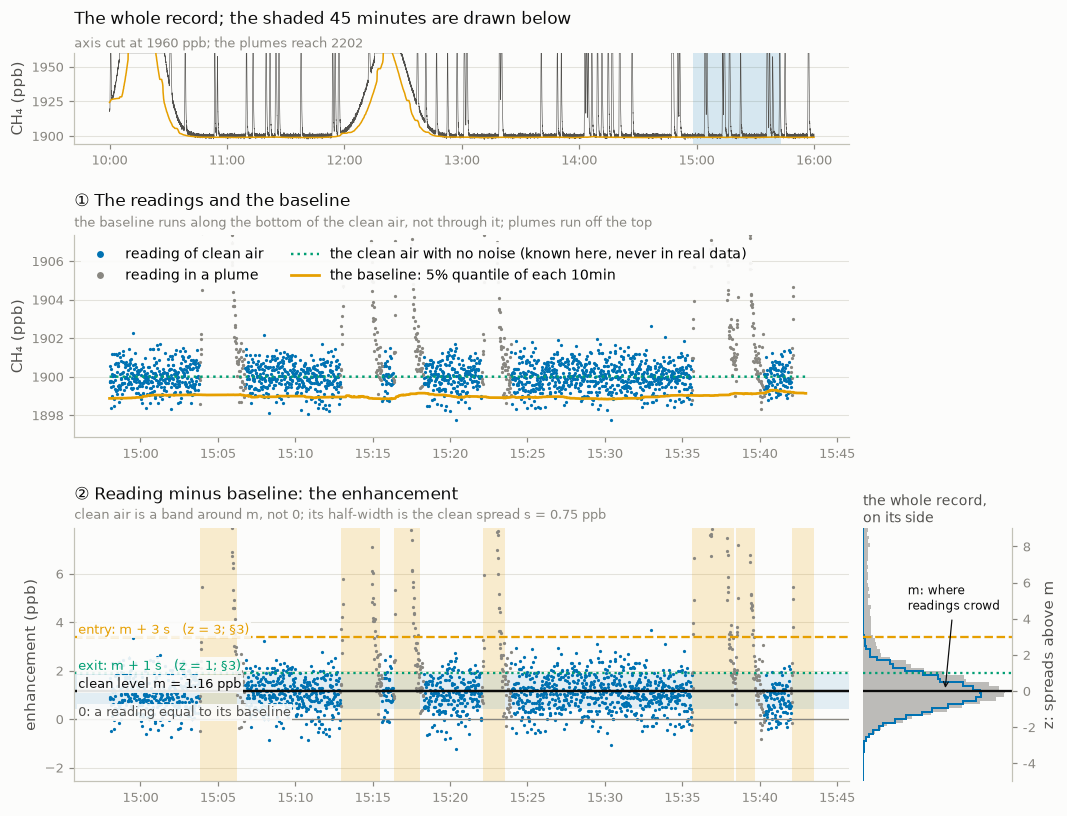

In [5]:
# Figure only: the whole record, then the three steps over a 45 minute stretch.
t = pd.to_datetime(stream["time"].values)
x = stream["ch4"].values
base = state["baseline_ch4"].values[:, 0, 0]
true_air = campaign.streams["analyzer"]["truth_background_ch4"].values
plume = true_plume >= 0.1 * sigma
event = found["event_ch4"].values[:, 0, 0, 0, 0]
cells = stream_cells(stream, "analyzer")
z0 = pd.Timestamp(f"{t[0]:%Y-%m-%d} {ZOOM_START}")
z1 = z0 + pd.Timedelta(minutes=ZOOM_MINUTES)
zoom = (t >= z0) & (t < z1)
box = {"facecolor": SURFACE, "edgecolor": "none", "alpha": 0.9, "pad": 1.0}

fig = plt.figure(figsize=(11, 8.6))
grid = fig.add_gridspec(
    3, 2, width_ratios=[5.2, 1], height_ratios=[0.9, 2.0, 2.5], hspace=0.5, wspace=0.03
)
over = fig.add_subplot(grid[0, 0])
top = fig.add_subplot(grid[1, 0])
low = fig.add_subplot(grid[2, 0], sharex=top)
side = fig.add_subplot(grid[2, 1])

# the whole record, the stretch below shaded
ceiling = np.nanmax(true_air) + 60
over.plot(t, np.minimum(x, ceiling), color=INK2, lw=0.4)
over.plot(t, base, color=C2, lw=1.0)
over.axvspan(z0, z1, color=C1, alpha=0.15, lw=0)
over.set_ylim(np.nanmin(x) - 3, ceiling)
hhmm(over)
finish(
    over,
    f"The whole record; the shaded {ZOOM_MINUTES} minutes are drawn below",
    f"axis cut at {ceiling:.0f} ppb; the plumes reach {np.nanmax(x):.0f}",
    "CH₄ (ppb)",
)

# 1: the readings and the baseline
low1 = np.nanpercentile(x[zoom], 0.5)
top.plot(t[zoom & ~plume], x[zoom & ~plume], ".", ms=2.2, color=C1)
top.plot(t[zoom & plume], x[zoom & plume], ".", ms=2.2, color=MUTED)
top.plot(t[zoom], true_air[zoom], color=C3, lw=1.6, ls=":")
top.plot(t[zoom], base[zoom], color=C2, lw=1.8)
top.set_ylim(low1 - 1.5, low1 + 9)
handles = [
    plt.Line2D([], [], ls="", marker=".", ms=7, color=C1, label="reading of clean air"),
    plt.Line2D([], [], ls="", marker=".", ms=7, color=MUTED, label="reading in a plume"),
    plt.Line2D(
        [],
        [],
        color=C3,
        lw=1.6,
        ls=":",
        label="the clean air with no noise (known here, never in real data)",
    ),
    plt.Line2D(
        [], [], color=C2, lw=1.8, label=f"the baseline: {QUANTILE:.0%} quantile of each {WINDOW}"
    ),
]
top.legend(
    handles=handles,
    loc="upper left",
    ncol=2,
    frameon=True,
    facecolor=SURFACE,
    edgecolor="none",
    framealpha=0.93,
)
finish(
    top,
    "① The readings and the baseline",
    "the baseline runs along the bottom of the clean air, not through it; plumes run off the top",
    "CH₄ (ppb)",
)

# 2: the enhancement, the clean level, the spread, and the thresholds
ceiling2 = level + 9 * spread
for k in np.unique(event[zoom & (event >= 0)]):
    rows = np.flatnonzero(event == k)
    real = plume[rows].any()
    low.axvspan(
        pd.Timestamp(int(cells.start_ns[rows[0]])),
        pd.Timestamp(int(cells.stop_ns[rows[-1]])),
        color=C2 if real else MUTED,
        alpha=0.18 if real else 0.35,
        lw=0,
    )
low.plot(t[zoom & ~plume], delta[zoom & ~plume], ".", ms=2.2, color=C1)
low.plot(t[zoom & plume], delta[zoom & plume], ".", ms=2.2, color=MUTED)
low.axhline(0, color=MUTED, lw=0.9)
low.axhspan(level - spread, level + spread, color=C1, alpha=0.10, lw=0)
low.axhline(level, color=INK, lw=1.6)
low.axhline(level + spread, color=C3, lw=1.5, ls=":")
low.axhline(level + 3 * spread, color=C2, lw=1.5, ls="--")
low.set_ylim(min(-2.0, level - 5 * spread), ceiling2)
for value, text, colour in (
    (0.0, "0: a reading equal to its baseline", INK2),
    (level, f"clean level m = {level:.2f} ppb", INK),
    (level + spread, "exit: m + 1 s   (z = 1; §3)", C3),
    (level + 3 * spread, "entry: m + 3 s   (z = 3; §3)", C2),
):
    low.text(
        0.005,
        value,
        text,
        transform=low.get_yaxis_transform(),
        color=colour,
        fontsize=8.3,
        va="bottom",
        bbox=box,
    )
hhmm(low)
finish(
    low,
    "② Reading minus baseline: the enhancement",
    f"clean air is a band around m, not 0; its half-width is the clean spread s = {spread:.2f} ppb",
    "enhancement (ppb)",
)

# 3: the whole record's enhancement on its side, with the z ruler
bins = np.linspace(low.get_ylim()[0], ceiling2, 70)
finite = np.isfinite(delta)
side.hist(delta[finite], bins=bins, orientation="horizontal", color=MUTED, alpha=0.55)
side.stairs(
    np.histogram(delta[finite & ~plume], bins=bins)[0],
    bins,
    orientation="horizontal",
    baseline=None,
    color=C1,
    lw=1.3,
)
for value, style, colour in (
    (level, "-", INK),
    (level + spread, ":", C3),
    (level + 3 * spread, "--", C2),
):
    side.axhline(value, color=colour, lw=1.5, ls=style)
side.set_ylim(low.get_ylim())
side.tick_params(axis="y", left=False, labelleft=False, right=True, labelright=True)
ticks = [k for k in range(-8, 10, 2) if low.get_ylim()[0] <= level + k * spread <= ceiling2]
side.set_yticks([level + k * spread for k in ticks], [f"{k:d}" for k in ticks])
side.yaxis.set_label_position("right")
side.set_ylabel("z: spreads above m")
side.set_xticks([])
for spine in ("bottom", "left"):
    side.spines[spine].set_visible(False)
side.spines["right"].set_visible(True)
side.set_title("the whole record,\non its side", fontsize=9, color=INK2, pad=4)
side.annotate(
    "m: where\nreadings crowd",
    xy=(0.55, level),
    xycoords=("axes fraction", "data"),
    xytext=(0.3, level + 4.5 * spread),
    textcoords=("axes fraction", "data"),
    fontsize=8,
    color=INK,
    arrowprops={"arrowstyle": "->", "color": INK, "lw": 0.8},
)
plt.show()

In ① the baseline (amber) runs along the bottom of the clean air (blue dots),
about a noise σ and a half below the dotted line that marks the air with no
noise. In ② the same readings minus that baseline: clean air is a band around
*m*, not around 0, and the band's half-width is *s*. The histogram on the right
is the whole record on its side: the readings crowd at *m*, the plumes fill the
long tail upward, and nothing reaches far below, which is why the spread is
read from the lower side. The tick marks beside it are *z*, the ruler §3's
thresholds are drawn on. Shaded bands are the events §3 finds; a grey one holds
no plume.

**Try it.**
- `LANDFILL_PER_HOUR = 1.5` and `BLIPS_PER_HOUR = 40` make `METHODS.md` §6.8's
  *dense* record, where most readings sit in a plume. TSARA's level stays within
  about a third of a true spread of the truth, while the withdrawn midpoint of
  the shortest half, printed beside it, is off by several. That collapse is why
  it was withdrawn.
- `QUANTILE = 0.01`: the level rises from about 1.2 to 1.5 ppb. In plume-free
  air a 1st percentile sits about 2.3 σ below the air's typical value and a 5th
  about 1.6 σ, with σ 0.7 ppb here; the level measures that offset rather than
  assuming it.
- `CYCLE_PPB = 40` and `WINDOW = "60min"`: the air now falls through the
  record, and a 60 min baseline trails it, so the band moves up to a level of
  about 4.3 ppb and widens to about twice the noise; entry rises with it and no
  clean reading reaches it. At `WINDOW = "10min"` the level stays near 1.16 ppb,
  because a 10 min baseline follows the fall.
- `CYCLE_PPB = 15`, `CYCLE_PERIOD = "4h"` and `WINDOW = "60min"`: air rising
  and falling over about the window's own length stands above a low quantile and
  never below it, as a broad plume does, so the lower side cannot see it: about
  45 % of clean readings stand above entry, in a few long events. TSARA records
  this as a property of the window, not a fault of the record (`METHODS.md`
  §6.8); the 10 min window, which follows the cycle, sees little of it.

---
## 2. Records: plume-free air is described one stretch at a time

**The question.** Over days of a ground site, or a van that logs parked and
driving alike, one level and one spread would mix air that was never the same.
So each variable's finite readings are split into **records**
(`find_records` in `src/tsara/events/records.py`):

- a new record starts where two readings are more than `record_gap` apart
  (default 2 h);
- where the configuration names the platform's speed (`platform_state`), it
  also starts at both ends of any stop that lasts at least `record_gap`, as an
  outage does. A moving stretch never splits, so a shorter stop, at a light or a
  sampling site, stays with the drive around it, which is what a drive looks
  like;
- a piece longer than `max_record_length` (default 6 h) is cut into the fewest
  equal parts no longer than it.

A record also fixes what a **dropout** is: two consecutive finite readings more
than 1.5 × the record's median spacing apart. A dropout whose hole is shorter
than `max_bridged_dropout` (default 5 s) is bridged as a short dip is, so that
one missing row does not split a plume in two; nothing is filled in, and the
event records the hole in its covered share. A longer hole ends an event.

The stream here is a day of 1 s cells with a three-hour outage, one missing
reading, and the platform parked for three hours. Below it, a plume is drawn
across the missing reading to show the bridge.

In [6]:
# ---- PARAMETERS (section 2) --------------------------------------------------
HOURS = 24  # length of the stream (1 s cells)
OUTAGE = (6.0, 9.0)  # hours into the stream: nothing is recorded
MISSING_AT = 12.0  # hours into the stream: one reading is missing
PARKED = (14.0, 17.0)  # hours into the stream: the platform is parked (moving otherwise)
RECORD_GAP = "2h"
MAX_RECORD_LENGTH = "6h"
MAX_BRIDGED_DROPOUT = "5s"  # a hole shorter than this does not end an event

In [7]:
start_section("§2")
start = pd.Timestamp("2026-06-15T00:00:00").value
starts = start + np.arange(HOURS * 3600, dtype=np.int64) * SECOND
cells = CellBounds(start_ns=starts, stop_ns=starts + SECOND)
hours = (starts - start) / HOUR
finite = ~((hours >= OUTAGE[0]) & (hours < OUTAGE[1]))
missing = int(np.argmin(np.abs(hours - MISSING_AT)))
finite[missing] = False
parked = (hours >= PARKED[0]) & (hours < PARKED[1])  # whether the platform is parked, per reading

gap_ns, max_ns = pd.Timedelta(RECORD_GAP).value, pd.Timedelta(MAX_RECORD_LENGTH).value
records = find_records(cells, finite, gap_ns=gap_ns, max_length_ns=max_ns, parked=parked)
print(
    f"{'record':>6} {'from (h)':>9} {'to (h)':>7} {'hours':>6} {'readings':>9} "
    f"{'median spacing':>15} {'state':>8}"
)
for r in range(records.n):
    rows = records.index == r
    states = {"parked" if p else "moving" for p in parked[rows]}
    print(
        f"{r:>6} {(records.start_ns[r] - start) / HOUR:>9.2f} "
        f"{(records.stop_ns[r] - start) / HOUR:>7.2f} "
        f"{(records.stop_ns[r] - records.start_ns[r]) / HOUR:>6.2f} {rows.sum():>9} "
        f"{records.median_spacing_ns[r] / SECOND:>13.1f} s {' and '.join(sorted(states)):>8}"
    )
dropouts = hours[records.dropout_before]
print(f"dropouts (hours into the stream): {[round(float(h), 3) for h in dropouts]}")

by_hand = reference_records(cells.midpoint_ns, finite, gap_ns, max_ns, parked=parked)
check(
    "§2 every reading's record is the definition's, reading by reading",
    np.array_equal(records.index, by_hand),
)
check(
    "§2 no record is longer than the maximum length",
    np.all(records.stop_ns - records.start_ns <= max_ns + SECOND),
)
check(
    "§2 no record spans a gap longer than the record gap",
    all(np.all(np.diff(cells.midpoint_ns[records.index == r]) <= gap_ns) for r in range(records.n)),
)
stop_lasts = (PARKED[1] - PARKED[0]) * HOUR >= gap_ns
check(
    "§2 a stop shares a record with the drive exactly when it is shorter than the record gap",
    any(len(set(parked[records.index == r])) == 2 for r in range(records.n)) != stop_lasts,
)
# Dropouts from the definition, one step at a time: a step between consecutive
# finite readings of one record longer than 1.5 x that record's median step. A
# step across a record's edge is none: the edge already breaks any event.
kept = np.flatnonzero(finite)
steps_of = {}
for a, b in zip(kept[:-1], kept[1:]):
    if by_hand[a] == by_hand[b]:
        steps_of.setdefault(by_hand[a], []).append(
            (b, int(cells.midpoint_ns[b] - cells.midpoint_ns[a]))
        )
hand_dropouts = []
for steps in steps_of.values():
    typical = np.median([step for _, step in steps])
    hand_dropouts += [b for b, step in steps if step > 1.5 * typical]
hand_dropouts.sort()
check(
    "§2 the dropouts are the definition's: steps within a record over 1.5 x its median step",
    np.array_equal(np.flatnonzero(records.dropout_before), hand_dropouts),
    f"{len(hand_dropouts)} found",
)

# A plume across the missing reading: z rises to 6 over a Gaussian of sigma 60 s,
# zero elsewhere, with no noise, so that the events can be counted by eye.
z_demo = np.where(finite, 6.0 * np.exp(-0.5 * ((hours - MISSING_AT) * 3600 / 60.0) ** 2), np.nan)
bridge_ns = pd.Timedelta(MAX_BRIDGED_DROPOUT).value
for label, hole_ns in (
    (f"holes under {MAX_BRIDGED_DROPOUT} bridged", bridge_ns),
    ("nothing bridged", 0),
):
    demo = find_events(
        z_demo,
        cells,
        records,
        enter=3.0,
        exit_=1.0,
        max_internal_gap_ns=0,
        max_bridged_dropout_ns=hole_ns,
    )
    hand = reference_events(
        z_demo, cells, records.dropout_before, records.index, 3.0, 1.0, 0, hole_ns
    )
    covering = [round(float(c), 4) for c in demo.covered]
    print(f"the plume across the missing reading, {label}: {demo.n} event(s), covering {covering}")
    check(
        f"§2 with {label}, every reading's event is the definition's",
        np.array_equal(demo.membership, hand),
    )

record  from (h)  to (h)  hours  readings  median spacing    state
     0      0.00    6.00   6.00     21600           1.0 s   moving
     1      9.00   14.00   5.00     17999           1.0 s   moving
     2     14.00   17.00   3.00     10800           1.0 s   parked
     3     17.00   20.50   3.50     12600           1.0 s   moving
     4     20.50   24.00   3.50     12600           1.0 s   moving
dropouts (hours into the stream): [12.0]


  ✔ §2 every reading's record is the definition's, reading by reading
  ✔ §2 no record is longer than the maximum length
  ✔ §2 no record spans a gap longer than the record gap
  ✔ §2 a stop shares a record with the drive exactly when it is shorter than the record gap


  ✔ §2 the dropouts are the definition's: steps within a record over 1.5 x its median step   [1 found]


the plume across the missing reading, holes under 5s bridged: 1 event(s), covering [0.9956]
  ✔ §2 with holes under 5s bridged, every reading's event is the definition's


the plume across the missing reading, nothing bridged: 2 event(s), covering [1.0, 1.0]
  ✔ §2 with nothing bridged, every reading's event is the definition's


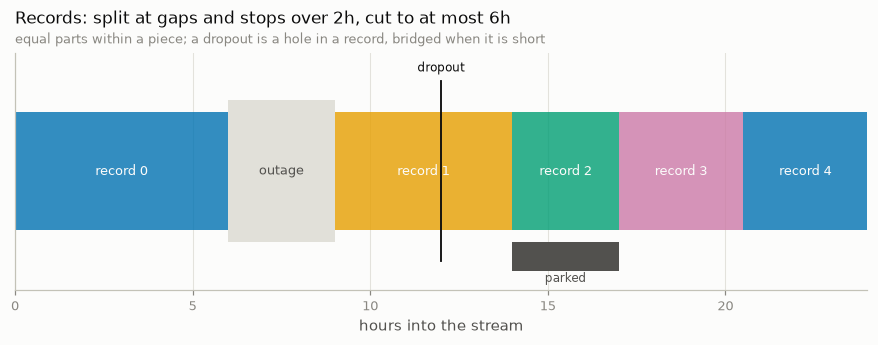

In [8]:
# Figure only: the stream's timeline, each record in its own colour, the holes and the stop marked.
fig, ax = plt.subplots(figsize=(10, 2.8))
palette = [C1, C2, C3, C4]
for r in range(records.n):
    ax.axvspan(
        (records.start_ns[r] - start) / HOUR,
        (records.stop_ns[r] - start) / HOUR,
        ymin=0.25,
        ymax=0.75,
        color=palette[r % 4],
        alpha=0.8,
        lw=0,
    )
    ax.text(
        ((records.start_ns[r] + records.stop_ns[r]) / 2 - start) / HOUR,
        0.5,
        f"record {r}",
        ha="center",
        va="center",
        fontsize=8.5,
        color=SURFACE,
    )
ax.axvspan(*OUTAGE, ymin=0.2, ymax=0.8, color=GRID, lw=0)
ax.text(np.mean(OUTAGE), 0.5, "outage", ha="center", va="center", fontsize=8.5, color=INK2)
ax.axvspan(*PARKED, ymin=0.08, ymax=0.2, color=INK2, lw=0)
ax.text(np.mean(PARKED), 0.02, "parked", ha="center", va="bottom", fontsize=8, color=INK2)
for h in dropouts:
    ax.plot([h, h], [0.12, 0.88], color=INK, lw=1.2)
if dropouts.size:
    ax.text(MISSING_AT, 0.92, "dropout", ha="center", fontsize=8, color=INK)
ax.set_xlim(0, HOURS)
ax.set_ylim(0, 1)
ax.set_yticks([])
finish(
    ax,
    f"Records: split at gaps and stops over {RECORD_GAP}, cut to at most {MAX_RECORD_LENGTH}",
    "equal parts within a piece; a dropout is a hole in a record, bridged when it is short",
    None,
    "hours into the stream",
    grid_axis="x",
)
plt.show()

The outage splits the day, and the three hours parked are a record of their
own, since the stop lasts longer than the record gap; each piece is then cut
into equal parts no longer than six hours. The single missing reading is a
dropout, because its neighbours are 2 s apart against the record's median of
1 s. The rule reads the record's own median, so an analyzer that reports every
2 or 3 s throughout (the 2024 Picarro, median 2 s) is not full of dropouts: only
a step longer than 3 s would be one. The last lines are the bridge: the plume
across that one-second hole is one event, its covered share a little under one
for the second it does not have; with nothing bridged it is two events, the
rule before 2026-09-30, which on the archive's ARC merge file, missing single
seconds of its Aeris dozens of times an hour, split one plume into many
(notebook 06b).

**Try it.**
- `PARKED = (14.0, 15.5)`: a stop of an hour and a half is shorter than the
  record gap, so it stays with the drive around it, though the legs either side
  of it last longer than the gap: the drive from 9 to 24 h is one piece, cut
  into three parts of five hours.
- `RECORD_GAP = "4h"`: neither the outage nor the stop is long enough to split
  anything, so the whole day is one piece, cut into four parts of six hours.
  The cuts fall at 6 and 12 h, right on the outage and on the missing reading,
  so neither is a dropout now: a record's edge is there instead, and the plume
  across the missing reading is two events even with the bridge. Where a cut
  falls is arbitrary (§8).
- `MAX_BRIDGED_DROPOUT = "1s"`: a one-second hole is no longer shorter than the
  bridge, so the plume splits in two.

---
## 3. The detector: two thresholds, and how often chance crosses them

**The question.** Given *z* at every reading, where are the events? An event is a
run of readings with *z* ≥ exit that holds at least one with *z* ≥ entry
(`find_events` in `src/tsara/events/hysteresis.py`). **Entry decides whether
there is an event; exit decides where it starts and ends.** A single line
cannot do both: low, it calls noise an event; high, it cuts a plume hovering
near it into fragments and loses its flanks. The first figure shows the three
choices on one weak plume. A dip below exit shorter than `max_internal_gap` is
bridged, a short hole likewise (§2), and there is no minimum duration: width
cannot tell a chance crossing from a narrow plume (`METHODS.md` §9.5, §6.8).

In [9]:
# ---- PARAMETERS (section 3) --------------------------------------------------
ENTER = 3.0  # entry multiple
EXIT = 1.0  # exit multiple (must be below ENTER)
MAX_INTERNAL_GAP = "5s"  # dips below exit shorter than this are bridged
WEAK_SEED = 3  # the quiet record whose weakest plume the first figure draws
WINDOW = "2min"  # the plume-dense record of the second figure
SEED = 5
CHANCE_HOURS = 100  # hours of independent 1 s readings for the chance count
CHANCE_ENTRIES = (2.0, 3.0, 4.0)
CHANCE_EXIT = 1.0  # the chance count's own exit, below every entry
CHANCE_SEED = 12

In [10]:
start_section("§3")
gap_ns = pd.Timedelta(MAX_INTERNAL_GAP).value
hole_ns = pd.Timedelta(EventsConfig().max_bridged_dropout).value

# One weak plume, cut three ways by TSARA's own detector: a single line is an
# entry and an exit a hair apart.
weak = weak_plume_campaign(seed=WEAK_SEED)
weak_stream = weak.observable("analyzer")
weak_state = baseline_state(weak_stream, instrument="analyzer", baseline=sweep(windows=("10min",)))
weak_found = event_state(
    weak_state,
    instrument="analyzer",
    events=thresholds((ENTER,), (EXIT,), max_internal_gap=MAX_INTERNAL_GAP),
)
weak_z = weak_found["z_ch4"].values[:, 0, 0]
weak_cells = stream_cells(weak_stream, "analyzer")
weak_records = find_records(
    weak_cells, np.isfinite(weak_z), gap_ns=2 * HOUR, max_length_ns=6 * HOUR
)
ways = {
    f"one line at z = {EXIT:g}": (EXIT + 1e-9, EXIT),
    f"one line at z = {ENTER:g}": (ENTER, ENTER - 1e-9),
    f"entry {ENTER:g}, exit {EXIT:g} (TSARA)": (ENTER, EXIT),
}
cut = {
    name: find_events(
        weak_z,
        weak_cells,
        weak_records,
        enter=a,
        exit_=b,
        max_internal_gap_ns=gap_ns,
        max_bridged_dropout_ns=hole_ns,
    ).membership
    for name, (a, b) in ways.items()
}
single, both = cut[f"one line at z = {ENTER:g}"], cut[f"entry {ENTER:g}, exit {EXIT:g} (TSARA)"]
check(
    "§3 every event a single line at entry finds lies inside one event of entry and exit",
    all(
        len(set(both[single == k])) == 1 and both[single == k][0] >= 0
        for k in np.unique(single[single >= 0])
    ),
)

  ✔ §3 every event a single line at entry finds lies inside one event of entry and exit


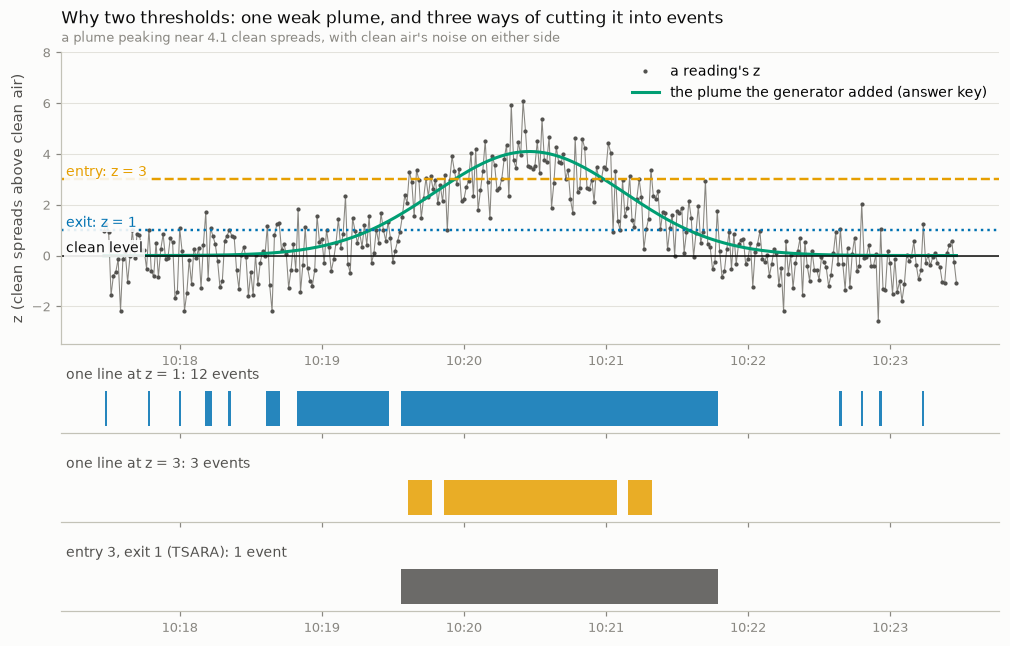

In [11]:
# Figure only: the plume a single line at entry cuts into the most pieces, and the three cuts.
weak_t = pd.to_datetime(weak_stream["time"].values)
weak_plume = weak.streams["analyzer"]["truth_enhancement_ch4"].values
weak_spread = float(weak_found["clean_spread_ch4"].values[0, 0, 0])
inside = weak_plume >= 0.07
starts_ = np.flatnonzero(inside & ~np.r_[False, inside[:-1]])
stops_ = np.flatnonzero(inside & ~np.r_[inside[1:], False])
pieces = [len(set(single[a : b + 1]) - {-1}) for a, b in zip(starts_, stops_)]
a, b = starts_[int(np.argmax(pieces))], stops_[int(np.argmax(pieces))]
peak = a + int(np.argmax(weak_plume[a : b + 1]))
near = (weak_t >= weak_t[peak] - pd.Timedelta(minutes=3)) & (
    weak_t <= weak_t[peak] + pd.Timedelta(minutes=3)
)
box = {"facecolor": SURFACE, "edgecolor": "none", "alpha": 0.9, "pad": 1.0}

fig = plt.figure(figsize=(11, 6.6))
grid = fig.add_gridspec(4, 1, height_ratios=[3.2, 0.55, 0.55, 0.55], hspace=0.35)
ax = fig.add_subplot(grid[0])
ax.plot(weak_t[near], weak_z[near], color=MUTED, lw=0.7)
ax.plot(weak_t[near], weak_z[near], ".", color=INK2, ms=3.5, label="a reading's z")
ax.plot(
    weak_t[near],
    weak_plume[near] / weak_spread,
    color=C3,
    lw=2.0,
    label="the plume the generator added (answer key)",
)
ax.axhline(ENTER, color=C2, lw=1.6, ls="--")
ax.axhline(EXIT, color=C1, lw=1.6, ls=":")
ax.axhline(0, color=INK, lw=1.0)
for value, text, colour in (
    (ENTER, f"entry: z = {ENTER:g}", C2),
    (EXIT, f"exit: z = {EXIT:g}", C1),
    (0, "clean level", INK),
):
    ax.text(
        0.005,
        value,
        text,
        transform=ax.get_yaxis_transform(),
        color=colour,
        fontsize=9,
        va="bottom",
        bbox=box,
    )
ax.set_ylim(-3.5, 8)
ax.legend(loc="upper right")
hhmm(ax)
finish(
    ax,
    "Why two thresholds: one weak plume, and three ways of cutting it into events",
    f"a plume peaking near {weak_plume[peak] / weak_spread:.1f} clean spreads, "
    "with clean air's noise on either side",
    "z (clean spreads above clean air)",
)
colours = dict(zip(ways, (C1, C2, INK2)))
for row, (name, member) in enumerate(cut.items(), start=1):
    strip = fig.add_subplot(grid[row], sharex=ax)
    shown = sorted(set(member[near]) - {-1})
    for k in shown:
        rows = np.flatnonzero(member == k)
        strip.axvspan(
            pd.Timestamp(int(weak_cells.start_ns[rows[0]])),
            pd.Timestamp(int(weak_cells.stop_ns[rows[-1]])),
            ymin=0.15,
            ymax=0.85,
            color=colours[name],
            alpha=0.85,
            lw=0,
        )
    strip.set_yticks([])
    strip.text(
        0.005,
        1.02,
        f"{name}: {len(shown)} event{'s' if len(shown) != 1 else ''}",
        transform=strip.transAxes,
        fontsize=9,
        color=INK2,
        va="bottom",
    )
    for spine in ("left", "top", "right"):
        strip.spines[spine].set_visible(False)
    hhmm(strip)
    if row < 3:
        plt.setp(strip.get_xticklabels(), visible=False)
plt.show()

One line at the exit level calls the noise either side of the plume a dozen
events. One line at the entry level finds the plume but cuts it into pieces
wherever the noise dips below the line, and misses its flanks. Entry and exit
together find it once, from where it rises out of the noise to where it falls
back.

**On a real record.** Below, the detector on a three-hour record whose first half
is filled by a landfill plume, at a 2 min window. The check compares every
reading's event against a loop written from the definition (the toolkit's
`reference_events`). Then the figure asks the answer key which events hold a
plume.

In [12]:
campaign = landfill_campaign(seed=SEED, duration="3h")
state = baseline_state(
    campaign.observable("analyzer"), instrument="analyzer", baseline=sweep(windows=(WINDOW,))
)
config = thresholds((ENTER,), (EXIT,), max_internal_gap=MAX_INTERNAL_GAP)
found = event_state(state, instrument="analyzer", events=config)
z = found["z_ch4"].values[:, 0, 0]
membership = found["event_ch4"].values[:, 0, 0, 0, 0]
cells = stream_cells(state, "analyzer")
records = find_records(
    cells, np.isfinite(state["ch4"].values), gap_ns=2 * HOUR, max_length_ns=6 * HOUR
)
by_hand = reference_events(
    z, cells, records.dropout_before, records.index, ENTER, EXIT, gap_ns, hole_ns
)
events = int(found["n_events_ch4"].values[0, 0, 0, 0])
chance = float(found["chance_events_ch4"].values[0, 0, 0, 0])

# Which events hold a plume, by the answer key (a reading whose true plume reaches 1 sigma),
# and how well this record's plume-free air is described.
true_plume = campaign.streams["analyzer"]["truth_enhancement_ch4"].values
no_plume = [k for k in range(events) if true_plume[membership == k].max() < 0.7]
delta = state["enhancement_ch4"].values[:, 0, 0]
plume_free = (true_plume < 0.07) & np.isfinite(z)
true_level = float(np.median(delta[plume_free]))
true_spread = 1.4826 * float(np.median(np.abs(delta[plume_free] - true_level)))
level = float(found["clean_level_ch4"].values[0, 0, 0])
spread = float(found["clean_spread_ch4"].values[0, 0, 0])
crossing = float(np.mean(z[plume_free] >= ENTER))
print(
    f"events at entry {ENTER:g}, exit {EXIT:g}: {events}, {len(no_plume)} of them with no plume; "
    f"the chance column expects {chance:.1f}"
)
print(
    f"clean level {level:.2f} ppb against the plume-free readings' {true_level:.2f}; "
    f"spread {spread:.2f} against {true_spread:.2f}; z reaches entry at {crossing:.2%} of "
    f"plume-free readings, {crossing / norm.sf(ENTER):.1f} x the rate for noise described exactly"
)
check(
    "§3 every reading's event is the one a loop over the definition finds",
    np.array_equal(membership, by_hand),
)
check(
    "§3 every event holds a reading at or above entry",
    all(np.nanmax(z[membership == k]) >= ENTER for k in range(events)),
)
dips_ok = True
for k in range(events):
    rows = np.flatnonzero(membership == k)
    above = rows[z[rows] >= EXIT]
    for i in rows[z[rows] < EXIT]:  # a member below exit must sit in a dip shorter than the gap
        before, after = above[above < i].max(), above[above > i].min()
        dips_ok &= max(cells.start_ns[after] - cells.stop_ns[before], 0) < gap_ns
check("§3 a reading below exit is in an event only inside a dip shorter than the gap", dips_ok)

events at entry 3, exit 1: 78, 41 of them with no plume; the chance column expects 14.6
clean level 0.85 ppb against the plume-free readings' 1.10; spread 0.62 against 0.71; z reaches entry at 1.23% of plume-free readings, 9.1 x the rate for noise described exactly
  ✔ §3 every reading's event is the one a loop over the definition finds
  ✔ §3 every event holds a reading at or above entry
  ✔ §3 a reading below exit is in an event only inside a dip shorter than the gap


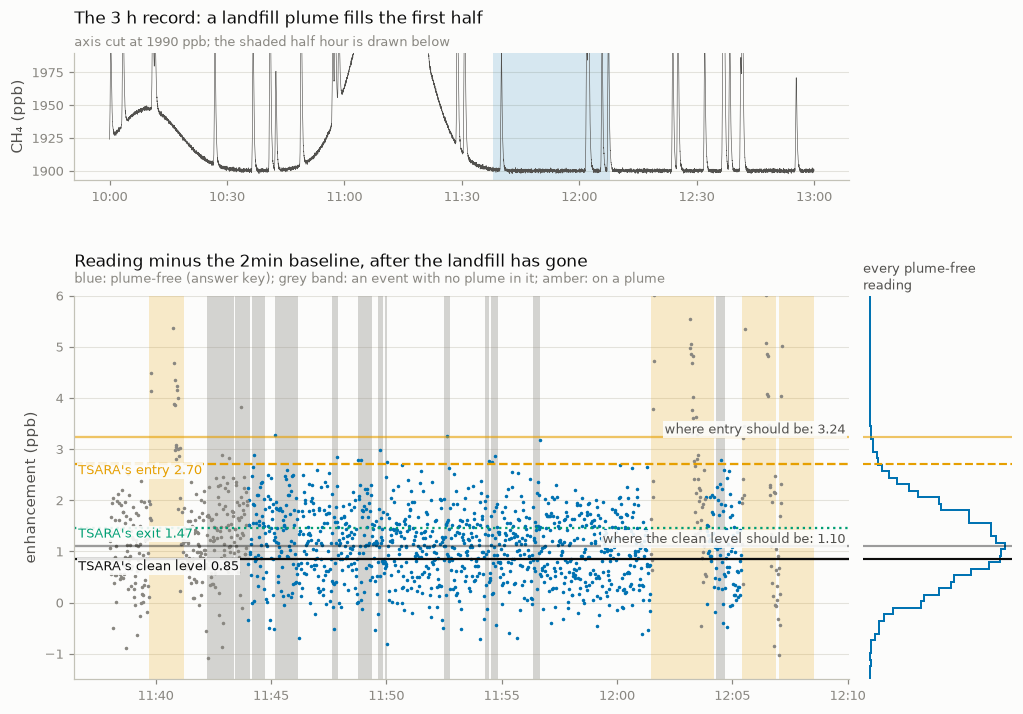

In [13]:
# Figure only: half an hour after the landfill has gone, in §1's picture.
t = pd.to_datetime(state["time"].values)
x = state["ch4"].values
plume = true_plume >= 0.07
zoom_from = t[0] + pd.Timedelta("98min")
zoom = (t >= zoom_from) & (t < zoom_from + pd.Timedelta("30min"))
box = {"facecolor": SURFACE, "edgecolor": "none", "alpha": 0.9, "pad": 1.0}
fig = plt.figure(figsize=(11, 7.4))
grid = fig.add_gridspec(
    2, 2, width_ratios=[5.2, 1], height_ratios=[1.0, 3.0], hspace=0.45, wspace=0.03
)
over = fig.add_subplot(grid[0, 0])
over.plot(t, np.minimum(x, 1990), color=INK2, lw=0.4)
over.axvspan(t[zoom][0], t[zoom][-1], color=C1, alpha=0.15, lw=0)
over.set_ylim(np.nanmin(x) - 5, 1990)
hhmm(over)
finish(
    over,
    "The 3 h record: a landfill plume fills the first half",
    "axis cut at 1990 ppb; the shaded half hour is drawn below",
    "CH₄ (ppb)",
)
ax = fig.add_subplot(grid[1, 0])
for k in np.unique(membership[zoom & (membership >= 0)]):
    rows = np.flatnonzero(membership == k)
    empty = k in no_plume
    ax.axvspan(
        pd.Timestamp(int(cells.start_ns[rows[0]])),
        pd.Timestamp(int(cells.stop_ns[rows[-1]])),
        color=MUTED if empty else C2,
        alpha=0.35 if empty else 0.2,
        lw=0,
    )
ax.plot(t[zoom & ~plume], delta[zoom & ~plume], ".", ms=2.6, color=C1)
ax.plot(t[zoom & plume], delta[zoom & plume], ".", ms=2.6, color=MUTED)
for value, colour, style, alpha in (
    (level, INK, "-", 1.0),
    (level + spread * EXIT, C3, ":", 1.0),
    (level + spread * ENTER, C2, "--", 1.0),
    (true_level, INK, "-", 0.4),
    (true_level + true_spread * ENTER, C2, "-", 0.6),
):
    ax.axhline(value, color=colour, lw=1.5, ls=style, alpha=alpha)
for value, text, colour in (
    (level, f"TSARA's clean level {level:.2f}", INK),
    (level + spread * EXIT, f"TSARA's exit {level + spread * EXIT:.2f}", C3),
    (level + spread * ENTER, f"TSARA's entry {level + spread * ENTER:.2f}", C2),
):
    ax.text(
        0.005,
        value,
        text,
        transform=ax.get_yaxis_transform(),
        color=colour,
        fontsize=8.5,
        va="top",
        bbox=box,
    )
for value, text in (
    (true_level, f"where the clean level should be: {true_level:.2f}"),
    (
        true_level + true_spread * ENTER,
        f"where entry should be: {true_level + true_spread * ENTER:.2f}",
    ),
):
    ax.text(
        0.995,
        value,
        text,
        transform=ax.get_yaxis_transform(),
        color=INK2,
        fontsize=8.5,
        va="bottom",
        ha="right",
        bbox=box,
    )
ax.set_ylim(-1.5, 6)
hhmm(ax)
finish(
    ax,
    f"Reading minus the {WINDOW} baseline, after the landfill has gone",
    "blue: plume-free (answer key); grey band: an event with no plume in it; amber: on a plume",
    "enhancement (ppb)",
)
side = fig.add_subplot(grid[1, 1])
bins = np.linspace(-1.5, 6, 60)
side.stairs(
    np.histogram(delta[plume_free], bins=bins)[0],
    bins,
    orientation="horizontal",
    baseline=None,
    color=C1,
    lw=1.3,
)
for value, style, colour, alpha in (
    (level, "-", INK, 1.0),
    (level + spread * ENTER, "--", C2, 1.0),
    (true_level, "-", INK, 0.4),
    (true_level + true_spread * ENTER, "-", C2, 0.6),
):
    side.axhline(value, color=colour, lw=1.4, ls=style, alpha=alpha)
side.set_ylim(-1.5, 6)
side.set_xticks([])
side.set_yticks([])
for spine in ("bottom", "left"):
    side.spines[spine].set_visible(False)
side.set_title("every plume-free\nreading", fontsize=8.5, color=INK2, pad=4)
plt.show()

**What the figure shows.** The grey bands are real rows of the catalog: events
TSARA reported, which nothing screens out. Only the answer key can say they
hold no plume. They are there because this record's description of clean air
came out low. Its clean level sits below where the plume-free readings say it
should be and its spread too narrow, so entry sits lower than it should, and
clean air reaches it about nine times as often as correctly described noise
would. The plumes are not pulling it there: the half-sample mode of the
plume-free readings alone lands just as low. It is the estimator's own jitter
on the hour and a half of clean air this record holds (`METHODS.md` §6.8). The
same record at 10 min, or §4's six hours at 2 min, is described well. TSARA
counts these events rather than hiding them, and the chance column beside the
count (below) is the number to read them against. Whether an event is a plume
is judged across the sweep, in Phase 7, and false events of this kind mostly do
not recur at other windows and quantiles, where real plumes do (`METHODS.md`
§6.8, "What the sweep says about an event").

**How often chance crosses.** Plume-free air crosses any threshold now and
then. For independent Gaussian readings there is a closed form
(`expected_chance_rate` in `src/tsara/events/hysteresis.py`): with *p*ₓ and *p*ₑ
the chances that one reading exceeds the exit and entry multiples, a reading
opens a run above exit with probability (1 − *p*ₓ)*p*ₓ, the run's length is
geometric, and each reading in it reaches entry with probability *p*ₑ/*p*ₓ. The
event state records this expectation at every sweep point
(`chance_events_x`). Below, independent white noise on 1 s cells, counted by
the package's detector with nothing bridged and with 5 s bridged.

In [14]:
n = int(CHANCE_HOURS * 3600)
noise = np.random.default_rng(CHANCE_SEED).normal(
    size=n
)  # the textbook draw, not the package's generator
noise_starts = np.arange(n, dtype=np.int64) * SECOND
noise_cells = CellBounds(start_ns=noise_starts, stop_ns=noise_starts + SECOND)
noise_records = find_records(
    noise_cells, np.ones(n, dtype=bool), gap_ns=HOUR, max_length_ns=(CHANCE_HOURS + 1) * HOUR
)
rows = []
for enter in CHANCE_ENTRIES:
    counted = [
        find_events(
            noise,
            noise_cells,
            noise_records,
            enter=enter,
            exit_=CHANCE_EXIT,
            max_internal_gap_ns=bridge,
            max_bridged_dropout_ns=0,
        ).n
        for bridge in (0, 5 * SECOND)
    ]
    expected = n * expected_chance_rate(enter, CHANCE_EXIT)
    rows.append((enter, expected, *counted))
    print(
        f"entry {enter:g}: closed form {expected / CHANCE_HOURS:7.2f} an hour; "
        f"counted {counted[0] / CHANCE_HOURS:7.2f} "
        f"({(counted[0] - expected) / np.sqrt(expected):+.1f} Poisson SE); "
        f"dips under 5 s bridged {counted[1] / CHANCE_HOURS:7.2f}"
    )
check(
    "§3 the package's closed form is the one written out from the definition",
    all(
        np.isclose(expected_chance_rate(e, CHANCE_EXIT), chance_rate(e, CHANCE_EXIT), rtol=1e-12)
        for e in CHANCE_ENTRIES
    ),
)
check(
    "§3 on white noise the count agrees with the closed form within five Poisson standard errors",
    all(abs(plain - expected) < 5 * np.sqrt(max(expected, 1.0)) for _, expected, plain, _ in rows),
)
check(
    "§3 bridging never adds an event: it only merges",
    all(bridged <= plain for *_, plain, bridged in rows),
)

entry 2: closed form   79.74 an hour; counted   78.58 (-1.3 Poisson SE); dips under 5 s bridged   67.57
entry 3: closed form    4.85 an hour; counted    4.57 (-1.3 Poisson SE); dips under 5 s bridged    4.51
entry 4: closed form    0.11 an hour; counted    0.12 (+0.2 Poisson SE); dips under 5 s bridged    0.12
  ✔ §3 the package's closed form is the one written out from the definition
  ✔ §3 on white noise the count agrees with the closed form within five Poisson standard errors
  ✔ §3 bridging never adds an event: it only merges


Entry 2 is chance's territory: about 80 events an hour at 1 s, one every 45 s,
which is why the example sweep starts at 3 (about 5 an hour) and goes to 5. The
rate scales with the reading rate: a 10 Hz analyzer at entry 2 would make about
800 an hour. Bridging only merges events, so with dips bridged the closed form
is an upper bound for noise described correctly. It is a reference, not a
bound, for real air: a record described too low, like the one above (where the
column expects about 15 and the answer key counts 41 events with no plume), or
air wandering at the window's own scale (§1's Try-it) crosses more often, and a
count well above the column is the sign.

**Try it.**
- `WINDOW = "10min"`: the same record, described well; plume-free air no longer
  reaches entry, and the grey bands vanish from the figure (one event with no
  plume remains, of 16).
- `EXIT = 2.0`: runs end sooner, so events are shorter, and a stretch that
  hovered between 1 and 2 now splits one event in two: 78 events become 101.
  In the first figure the weak plume stays one event, a little shorter, and a
  single line at the new exit makes 5 events where one at 1 made 12.
- `MAX_INTERNAL_GAP = "1ns"`: nothing is bridged, and 78 events become 184:
  every dip below exit, however short, now ends an event.
- `CHANCE_HOURS = 10`: the counts scatter more about the closed form, and the
  checks still hold, because they are stated in standard errors.

---
## 4. The window decides what is a plume, and the tree links the scales

**The question.** A baseline at window *w* follows what is slower than about
*w* (`METHODS.md` §6.1), so what counts as a plume depends on the window. The
campaign is §1's: broad landfill plumes (Gaussian, σ 8 min) with short gas
blips on top. The blips stand out at every window. The landfill is subtler.
A low quantile of a window lying on a slope sits below the slope's middle by
about (½ − *q*)·*w*·slope, so at 2 min the baseline follows the landfill but
trails its flanks by several clean spreads: the landfill does not vanish, it
shows as its rising and falling flanks, split at its top, where the slope is
zero. From about 5 min on the baseline stays under the whole plume, and the
landfill is one event holding the blips.

Every window is computed, and the **tree** (`link_parents` in
`src/tsara/events/catalog.py`) links each event to the event at the nearest
longer window whose interval holds its peak, skipping a window where nothing
does. So a flank event at 2 min links to the landfill's event at 10 min, which
says what it is: the landfill seen through a short window. The link records
containment, not origin: scale is not source.

The events here come from the **catalog** (`event_catalog`, same file), one row
per event, variable and sweep point.

In [15]:
# ---- PARAMETERS (section 4) --------------------------------------------------
WINDOWS = ("2min", "10min", "60min")
BLIPS_PER_HOUR = 10.0  # short gas blips an hour, on top of the landfill
SEED = 5

In [16]:
start_section("§4")
campaign = landfill_campaign(seed=SEED, blips_per_hour=BLIPS_PER_HOUR)
state = baseline_state(
    campaign.observable("analyzer"), instrument="analyzer", baseline=sweep(WINDOWS)
)
found = event_state(state, instrument="analyzer", events=thresholds())
catalog = event_catalog({"analyzer": found}, {"analyzer": state})
truth = campaign.ground_truth.to_frame()
landfill = truth[truth["source_name"] == "landfill"]
blips = truth[(truth["source_name"] == "gas_line") & truth["sampled_peak_amplitude"].notna()]
seconds = [pd.Timedelta(w).total_seconds() for w in WINDOWS]
shortest, longest = min(seconds), max(seconds)
print(catalog.groupby("baseline_window").size().rename("events").to_string())
print(f"true landfill plumes: {len(landfill)}; true gas blips: {len(blips)}")


def holding(rows, when):
    """Return the event_id of the row whose interval holds `when`, or None."""
    hit = rows[(rows["start_time"] <= when) & (when < rows["end_time"])]
    return hit["event_id"].iloc[0] if len(hit) else None


at = {w: catalog[catalog["baseline_window"] == w] for w in seconds}
big_blips = blips[blips["sampled_peak_amplitude"] >= 10 * 0.7]
check(
    "§4 every gas blip of 10 sigma or more is found at the shortest window",
    all(holding(at[shortest], p) for p in big_blips["peak_time"]),
    f"{len(big_blips)} blips",
)
if longest >= 3600:
    check(
        "§4 every landfill plume is found at a window of an hour or more",
        all(holding(at[longest], p) for p in landfill["peak_time"]),
        f"{len(landfill)} plumes",
    )
linked = catalog[catalog["parent_event_id"].notna()]
parents = catalog.set_index("event_id").loc[linked["parent_event_id"]]
check(
    "§4 every parent is at a longer window and holds its child's peak",
    bool(
        (parents["baseline_window"].to_numpy() > linked["baseline_window"].to_numpy()).all()
        and (parents["start_time"].to_numpy() <= linked["peak_time"].to_numpy()).all()
        and (linked["peak_time"].to_numpy() < parents["end_time"].to_numpy()).all()
    ),
    f"{len(linked)} links",
)


def ancestors(event_id):
    """Follow parent links to the top of the tree."""
    chain = [event_id]
    rows = catalog.set_index("event_id")["parent_event_id"]
    while isinstance(rows.get(chain[-1]), str):
        chain.append(rows[chain[-1]])
    return chain


if longest >= 3600:
    # Blips within one landfill sigma (8 min) of a landfill peak sit well inside
    # the landfill's event, so their chains should reach it.
    near = [
        (p, lp)
        for p in big_blips["peak_time"]
        for lp in landfill["peak_time"]
        if abs(p - lp) < pd.Timedelta("8min")
    ]
    check(
        "§4 a blip near a landfill peak links, up the tree, to the event holding that peak",
        all(holding(at[longest], lp) in ancestors(holding(at[shortest], p)) for p, lp in near),
        f"{len(near)} blips",
    )

baseline_window
120.0     57
600.0     43
3600.0    56
true landfill plumes: 4; true gas blips: 69
  ✔ §4 every gas blip of 10 sigma or more is found at the shortest window   [69 blips]
  ✔ §4 every landfill plume is found at a window of an hour or more   [4 plumes]
  ✔ §4 every parent is at a longer window and holds its child's peak   [100 links]
  ✔ §4 a blip near a landfill peak links, up the tree, to the event holding that peak   [13 blips]


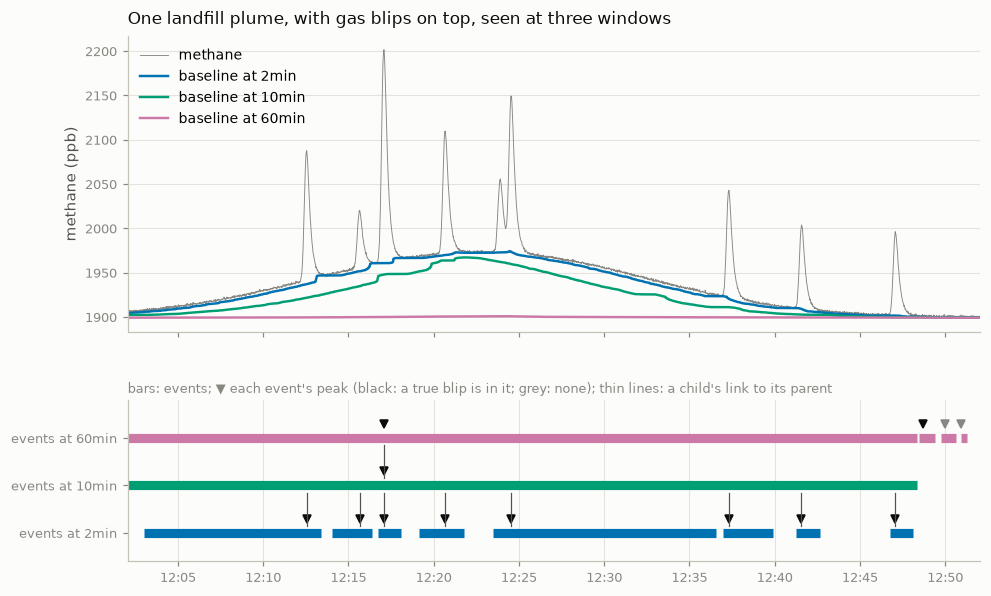

In [17]:
# Figure only: one landfill plume, its blips, the baselines, and the events at each window.
# The largest landfill plume at least 30 min from either end of the record.
first, last = pd.Timestamp(state["time"].values[0]), pd.Timestamp(state["time"].values[-1])
away = landfill[
    (landfill["peak_time"] > first + pd.Timedelta("30min"))
    & (landfill["peak_time"] < last - pd.Timedelta("30min"))
]
peak = away.loc[away["true_amplitude"].idxmax(), "peak_time"]
lo, hi = peak - pd.Timedelta("25min"), peak + pd.Timedelta("25min")
t = state["time"].values
inside = (t >= np.datetime64(lo)) & (t < np.datetime64(hi))
fig, (ax, lad) = plt.subplots(
    2, 1, figsize=(10, 6.2), sharex=True, gridspec_kw={"height_ratios": [2.2, 1.2], "hspace": 0.3}
)
ax.plot(t[inside], state["ch4"].values[inside], color=MUTED, lw=0.6, label="methane")
colours = [C1, C3, C4]
for w, (window, colour) in enumerate(zip(WINDOWS, colours)):
    ax.plot(
        t[inside],
        state["baseline_ch4"].values[inside, w, 0],
        color=colour,
        lw=1.6,
        label=f"baseline at {window}",
    )
finish(
    ax,
    "One landfill plume, with gas blips on top, seen at three windows",
    None,
    "methane (ppb)",
    legend=True,
    loc="upper left",
)


def holds_a_blip(row):
    """Whether a true gas blip's interval overlaps this event's."""
    return bool(
        ((blips["start_time"] < row["end_time"]) & (row["start_time"] < blips["end_time"])).any()
    )


for w, (window, colour) in enumerate(zip(WINDOWS, colours)):
    rows = at[seconds[w]]
    rows = rows[(rows["end_time"] > lo) & (rows["start_time"] < hi)]
    for _, row in rows.iterrows():
        lad.plot(
            [row["start_time"], row["end_time"]], [w, w], color=colour, lw=6, solid_capstyle="butt"
        )
        lad.plot(row["peak_time"], w + 0.3, "v", color=INK if holds_a_blip(row) else MUTED, ms=5)
        if isinstance(row["parent_event_id"], str):
            parent = catalog.set_index("event_id").loc[row["parent_event_id"]]
            level = seconds.index(parent["baseline_window"])
            lad.plot([row["peak_time"]] * 2, [w + 0.15, level - 0.15], color=INK2, lw=0.8)
lad.set_yticks(range(len(WINDOWS)), [f"events at {w}" for w in WINDOWS])
lad.set_ylim(-0.6, len(WINDOWS) - 0.2)
lad.set_xlim(lo, hi)
hhmm(lad)
finish(
    lad,
    None,
    "bars: events; ▼ each event's peak (black: a true blip is in it; grey: none); "
    "thin lines: a child's link to its parent",
    None,
    grid_axis="x",
)
plt.show()

At 2 min (blue) the baseline climbs with the landfill but a little behind it
on both flanks, so each flank is an event, and the top, where the baseline
catches up, is not. At 10 and 60 min the baseline stays under the plume, and
the landfill is one long event holding every blip. The thin lines are the
tree: each 2 min event links to the 10 min event holding its peak, and that
one to the 60 min event, skipping a window only where nothing holds the peak.

The markers say what each event's peak is: black where a true blip lies in the
event. Every 2 min event here peaks on a blip, but look at how long some of
them are: the one from about 12:23 to 12:37 is a blip and twelve minutes of the
landfill's falling flank after it, joined by exit, because a 2 min baseline
lags a falling slope by several clean spreads. So the landfill's flank readings
are carried into its children, and a parent's own readings cannot be recovered
by masking its 2 min children: on this record they cover about three quarters
of the landfill's hour-long event, and more than half of what they cover is
flank, not blip. `METHODS.md` §6.1 measures it, and records a baseline that
follows the slope as the way to leave the children blips only; how a parent's
ratio is fitted is open there.

**Try it.**
- `BLIPS_PER_HOUR = 0`: the landfill alone. At 2 min it is its two flanks,
  their markers grey, and nothing at its top; at 10 and 60 min it is one event.
- `WINDOWS = ("2min", "60min")`: with the middle window gone, every 2 min event
  inside the plume links straight to the landfill's 60 min event.

---
## 5. The catalog, and scoring it is a join

**The question.** Is every plume found, and how many events are not plumes?
The **catalog** (`event_catalog` in `src/tsara/events/catalog.py`) is one long
table, a row per event, variable and sweep point, keyed by `event_id`. The
columns it shares with the generator's answer key are spelled and typed the
same (`METHODS.md` §6.8), so scoring is `catalog.merge(truth, on=["instrument",
"species"])` and two comparisons: a true plume is **found** when a detected
interval holds its peak time, and a detected event is **false** when its
interval overlaps no true plume at all.

The campaign is the shipped example (`examples/configs/synthetic_example.yaml`):
its 2 s Picarro's methane over 6 h, crossed by a well pad's and a compressor's
plumes. At the defaults below, which are `METHODS.md` §6.8's rule, the last
check compares against the numbers printed there.

In [18]:
# ---- PARAMETERS (section 5) --------------------------------------------------
WINDOWS = ("2min", "10min", "60min")
ENTER = 3.0
EXIT = 1.0
MAX_INTERNAL_GAP = "1ns"  # nothing bridged, as METHODS §6.8 measured; the example config bridges 5s

In [19]:
start_section("§5")
campaign = generate(load_synthetic(CONFIGS / "synthetic_example.yaml"))
state = baseline_state(
    campaign.observable("picarro"), instrument="picarro", baseline=sweep(WINDOWS), variables=["ch4"]
)
config = thresholds((ENTER,), (EXIT,), max_internal_gap=MAX_INTERNAL_GAP)
found = event_state(state, instrument="picarro", events=config)
catalog = event_catalog({"picarro": found}, {"picarro": state})
hours = np.ptp(state["time"].values).astype("timedelta64[s]").astype(float) / 3600

print(f"{len(catalog)} rows; the first three, a few of the {len(catalog.columns)} columns:")
show = [
    "event_id",
    "parent_event_id",
    "start_time",
    "duration_s",
    "n_readings",
    "peak_enhancement",
    "peak_z",
]
print(catalog[show].head(3).to_string(index=False))

# Scoring: one join, two comparisons.
truth = campaign.ground_truth.to_frame()
truth = truth[truth["sampled_peak_amplitude"].notna()]  # plumes the instrument actually saw
pairs = catalog.merge(truth, on=["instrument", "species"], suffixes=("", "_true"))
holds_peak = (pairs["start_time"] <= pairs["peak_time_true"]) & (
    pairs["peak_time_true"] <= pairs["end_time"]
)
overlaps = (pairs["start_time_true"] <= pairs["end_time"]) & (
    pairs["start_time"] <= pairs["end_time_true"]
)
plumes_seen = truth[(truth["instrument"] == "picarro") & (truth["species"] == "ch4")]
seconds = [pd.Timedelta(w).total_seconds() for w in WINDOWS]
rows = []
print(
    f"\n{'window':>7} {'plumes':>7} {'found':>6} {'events':>7} {'false':>6} {'false /h':>9} "
    f"{'chance /h':>10}"
)
for w, window in enumerate(seconds):
    at = pairs["baseline_window"] == window
    n_found = pairs.loc[at & holds_peak, "event_id_true"].nunique()
    detected = catalog.loc[catalog["baseline_window"] == window, "event_id"]
    false = int((~detected.isin(pairs.loc[at & overlaps, "event_id"])).sum())
    chance = float(found["chance_events_ch4"].values[w, 0, 0, 0]) / hours
    rows.append((n_found, false / hours))
    print(
        f"{WINDOWS[w]:>7} {len(plumes_seen):>7} {n_found:>6} {len(detected):>7} {false:>6} "
        f"{false / hours:>9.2f} {chance:>10.2f}"
    )

shared = [c for c in CATALOG_COLUMNS if c in GROUND_TRUTH_COLUMNS]
check(
    "§5 every column the catalog shares with the answer key has its name and its type",
    all(catalog[c].dtype == truth[c].dtype for c in shared),
    f"{len(shared)} columns",
)
check(
    "§5 every event_id is unique and names its instrument, variable and sweep point",
    catalog["event_id"].is_unique
    and all(
        e.startswith(f"{i}.{s}/w{b:g}s/q{q:g}/e{n:g}/x{x:g}/")
        for e, i, s, b, q, n, x in zip(
            catalog["event_id"],
            catalog["instrument"],
            catalog["species"],
            catalog["baseline_window"],
            catalog["baseline_quantile"],
            catalog["enter_multiple"],
            catalog["exit_multiple"],
        )
    ),
)
check(
    "§5 every row's interval holds its peak, and covers between none and all of itself",
    bool(
        (
            (catalog["start_time"] <= catalog["peak_time"])
            & (catalog["peak_time"] < catalog["end_time"])
        ).all()
        and ((catalog["covered"] > 0) & (catalog["covered"] <= 1)).all()
    ),
)
check(
    "§5 the catalog holds, per sweep point, the events the event state counted",
    [int((catalog["baseline_window"] == s).sum()) for s in seconds]
    == [int(n) for n in found["n_events_ch4"].values[:, 0, 0, 0]],
)
# A false event is chance, not a missed plume: the answer key's plume at its peak.
reading = campaign.streams["picarro"]
peaks = np.searchsorted(reading["time"].values, catalog["peak_time"].to_numpy())
plume_at_peak = reading["truth_enhancement_ch4"].values[
    np.minimum(peaks, reading.sizes["time"] - 1)
]
false_rows = ~catalog["event_id"].isin(pairs.loc[overlaps, "event_id"]).to_numpy()
check(
    "§5 no false event has a true plume above the Picarro's 0.6 ppb noise at its peak",
    bool((plume_at_peak[false_rows] < 0.6).all()),
    f"{int(false_rows.sum())} false events",
)

# Where plume-free air sits against the baseline, half hour by half hour, at the
# longest window: the true background minus the baseline, relative to its median
# over the record (which also removes the Picarro's systematic offset), in spreads.
longest = len(WINDOWS) - 1
under = reading["truth_background_ch4"].values - state["baseline_ch4"].values[:, longest, 0]
spread = float(found["clean_spread_ch4"].values[0, longest, 0])
by_half_hour = (
    pd.Series((under - np.nanmedian(under)) / spread)
    .groupby(pd.DatetimeIndex(reading["time"].values).floor("30min"))
    .mean()
)
print(
    f"\nat {WINDOWS[longest]}, plume-free air against the baseline, per half hour, "
    f"in clean spreads: {' '.join(f'{v:+.1f}' for v in by_half_hour)}"
)
high = by_half_hour.index[by_half_hour > 1.0]
at_longest = (catalog["baseline_window"] == seconds[longest]).to_numpy() & false_rows
in_high = pd.DatetimeIndex(catalog.loc[at_longest, "peak_time"]).floor("30min").isin(high)
print(
    f"false events at {WINDOWS[longest]}: {int(at_longest.sum())}, of which {int(in_high.sum())} "
    f"in the {len(high)} half hours where that air sits over one spread high"
)
at_rule = (WINDOWS, ENTER, EXIT, MAX_INTERNAL_GAP) == (("2min", "10min", "60min"), 3.0, 1.0, "1ns")
if at_rule:
    check(
        "§5 at METHODS §6.8's rule: all 59 plumes found at every window; "
        "false 2.50, 4.00, 7.67 an hour",
        [r[0] for r in rows] == [59, 59, 59]
        and [round(r[1], 2) for r in rows] == [2.50, 4.00, 7.67],
    )

213 rows; the first three, a few of the 28 columns:
                       event_id                 parent_event_id          start_time  duration_s  n_readings  peak_enhancement    peak_z
picarro.ch4/w120s/q0.05/e3/x1/0 picarro.ch4/w600s/q0.05/e3/x1/0 2026-06-15 14:02:17       156.0          78         51.437756 83.725783
picarro.ch4/w120s/q0.05/e3/x1/1 picarro.ch4/w600s/q0.05/e3/x1/1 2026-06-15 14:05:31       140.0          70         22.429949 35.662673
picarro.ch4/w120s/q0.05/e3/x1/2 picarro.ch4/w600s/q0.05/e3/x1/2 2026-06-15 14:13:15         4.0           2          2.991198  3.454555

 window  plumes  found  events  false  false /h  chance /h
   2min      59     59      65     15      2.50       2.43
  10min      59     59      67     24      4.00       2.43
  60min      59     59      81     46      7.67       2.43
  ✔ §5 every column the catalog shares with the answer key has its name and its type   [10 columns]
  ✔ §5 every event_id is unique and names its instrument, variable 

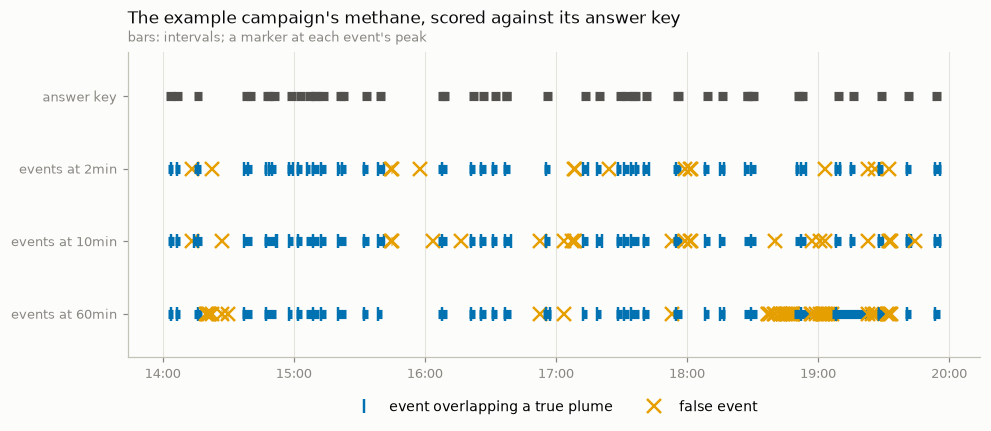

In [20]:
# Figure only: the answer key above, and each window's events below, over the whole record.
fig, ax = plt.subplots(figsize=(10, 3.6))
for _, plume in plumes_seen.iterrows():
    ax.hlines(len(WINDOWS), plume["start_time"], plume["end_time"], color=INK2, lw=6)
for w, window in enumerate(seconds):
    at = pairs["baseline_window"] == window
    touching = set(pairs.loc[at & overlaps, "event_id"])
    level = len(WINDOWS) - 1 - w
    for _, event in catalog[catalog["baseline_window"] == window].iterrows():
        real = event["event_id"] in touching
        colour, marker = (C1, "|") if real else (C2, "x")
        ax.hlines(level, event["start_time"], event["end_time"], color=colour, lw=6)
        ax.plot(event["peak_time"], level, marker, color=colour, ms=9, mew=1.6)
ax.plot([], [], "|", color=C1, ms=9, mew=1.6, label="event overlapping a true plume")
ax.plot([], [], "x", color=C2, ms=9, mew=1.6, label="false event")
ax.set_yticks(range(len(WINDOWS) + 1), [f"events at {w}" for w in WINDOWS[::-1]] + ["answer key"])
ax.set_ylim(-0.6, len(WINDOWS) + 0.6)
hhmm(ax)
finish(
    ax,
    "The example campaign's methane, scored against its answer key",
    "bars: intervals; a marker at each event's peak",
    None,
    grid_axis="x",
)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.1), ncol=2)
plt.show()

Every plume in the answer key is found at every window. The false events are
chance crossings, not missed plumes: none has a true plume above the noise at
its peak, and their peaks sit just past the entry line. How many there are
scatters about the chance column (§3's closed form, for this record's 2 s
readings) for two measured reasons. The clean spread is estimated from one
record, and the chance rate is steep in it: a spread 5 % low lets 1.6 times as
many crossings through at entry 3, one 5 % high 0.6 times (`METHODS.md` §6.8
records the scatter over seeds). And at 60 min the baseline no longer follows
the background's slow wander, so in some half hours plume-free air sits higher
against it than the record's one clean level expects. The printed lines show
where: 32 of the 46 false events at 60 min fall in the two half hours where
that air sits over a spread high, a sixth of the record (18:30 to 19:30 in the
figure). Nothing is deleted: the chance column says how many to expect from
noise alone. This per-view scoring is Phase 6's evidence, and the yardstick for
Phase 7, which judges events across the sweep: a consensus has to do better
than these numbers, scored by the same join.

**Try it.**
- `ENTER = 5.0`: no false event at any window, and every plume is still found;
  the example's plumes are large.
- `MAX_INTERNAL_GAP = "5s"`, the example config's value: dips shorter than 5 s
  are bridged, which merges fragments. Fewer events, the same plumes found, and
  at 60 min the crowded crossings of those two half hours merge: 46 false events
  become 6.

---
## 6. A sparse canister takes its events from a dense analyzer

**The question.** A whole-air canister is filled for 15 s every few minutes, so
over a 6 h record it holds tens of readings, too few to measure its own
plume-free air: a record with fewer than `min_clean_readings` (default 100)
readings below its level is **blank**, with the reason, and finds no events of
its own. It still needs to know which fills were taken in a plume. So it takes
its events from a dense instrument named in `triggers` (`METHODS.md` §6.8): each
of the trigger's event intervals becomes the canister's, and a fill belongs to
it when the fill's cell midpoint lies in [start, end). The trigger may measure
any field; here a 1 s benzene analyzer triggers the canister's benzene.

The canister's baseline is a declared constant of zero, so its enhancement is
its reading (notebook 05 §6); a trigger's intervals do not depend on that
choice.

In [21]:
# ---- PARAMETERS (section 6) --------------------------------------------------
FILL_EVERY = "300s"  # a canister is filled about this often, 15 s each
PLUMES_PER_HOUR = 3.0  # refinery plumes an hour (Gaussian, sigma 3 min)
WINDOW = "10min"
SEED = 21

In [22]:
start_section("§6")
campaign = canister_campaign(seed=SEED, fill_every=FILL_EVERY, plumes_per_hour=PLUMES_PER_HOUR)
settings = sweep((WINDOW,), methods={"iwas.benzene_can": {"method": "constant", "value": 0.0}})
baselines = {
    name: baseline_state(campaign.observable(name), instrument=name, baseline=settings)
    for name in ("ptr", "iwas")
}

# On its own: the canister describes its air only where enough fills lie below its level.
alone = event_states(baselines, thresholds())
level = alone["iwas"]["clean_level_benzene_can"].values
below = alone["iwas"]["n_clean_readings_benzene_can"].values
fills = int(np.isfinite(baselines["iwas"]["benzene_can"].values).sum())
print(f"canister fills: {fills}; the most below its clean level in a record: {int(below.max())}")
check(
    "§6 a record has a clean level exactly where at least min_clean_readings readings lie below it",
    np.array_equal(np.isnan(level), below < 100),
)

# With a trigger: the analyzer's intervals, the canister's own fills.
triggered = event_states(baselines, thresholds(triggers={"iwas": "ptr.benzene"}))
catalog = event_catalog(triggered, baselines)
canister = catalog[catalog["instrument"] == "iwas"]
analyzer = catalog[catalog["instrument"] == "ptr"].set_index("event_id")
their = analyzer.loc[canister["trigger_event_id"]]
midpoints = baselines["iwas"]["time"].values  # every stream's time is its cell midpoint
counted = [
    int(((midpoints >= a) & (midpoints < b)).sum())
    for a, b in zip(canister["start_time"], canister["end_time"])
]
print(f"analyzer events: {len(analyzer)}; canister rows: {len(canister)}")
check(
    "§6 every canister event is its trigger's interval exactly",
    bool(
        (canister["start_time"].to_numpy() == their["start_time"].to_numpy()).all()
        and (canister["end_time"].to_numpy() == their["end_time"].to_numpy()).all()
    ),
)
check(
    "§6 each canister event holds exactly the fills whose midpoints lie in [start, end)",
    canister["n_readings"].tolist() == counted,
)
holding = {
    event_id
    for event_id, a, b in zip(analyzer.index, analyzer["start_time"], analyzer["end_time"])
    if ((midpoints >= a) & (midpoints < b)).any()
}
check(
    "§6 the canister has a row for exactly the analyzer's events that hold one of its fills",
    set(canister["trigger_event_id"]) == holding,
    f"{len(holding)} of {len(analyzer)}",
)

# What the trigger buys: fills taken inside a true plume are in an event, clean fills mostly not.
truth = campaign.streams["iwas"]["truth_enhancement_benzene_can"].values
in_event = triggered["iwas"]["event_benzene_can"].values[:, 0, 0, 0, 0] >= 0
plumy, clean = truth > 0.2, truth < 0.02
print(
    f"fills in a true plume above 0.2 ppb: {plumy.sum()}, "
    f"in an event {in_event[plumy].mean():.0%}; "
    f"clean fills (under 0.02 ppb): {clean.sum()}, in an event {in_event[clean].mean():.0%}"
)
check(
    "§6 a fill in a plume above 0.2 ppb is more often in an event than a clean fill",
    plumy.sum() == 0 or clean.sum() == 0 or in_event[plumy].mean() > in_event[clean].mean(),
)

2026-10-01 10:46:05 | WARNING  | tsara.events.state | Event state of 'iwas': sweep points at which every record is blank, so no event is found -- benzene_can: 600 s, q 0.05 (at most 16). A record needs 100 readings below its clean level (METHODS 6.8); a sparse variable can take its events from a dense one named in events.triggers.


canister fills: 72; the most below its clean level in a record: 16
  ✔ §6 a record has a clean level exactly where at least min_clean_readings readings lie below it
analyzer events: 13; canister rows: 13
  ✔ §6 every canister event is its trigger's interval exactly
  ✔ §6 each canister event holds exactly the fills whose midpoints lie in [start, end)
  ✔ §6 the canister has a row for exactly the analyzer's events that hold one of its fills   [13 of 13]
fills in a true plume above 0.2 ppb: 32, in an event 100%; clean fills (under 0.02 ppb): 32, in an event 0%
  ✔ §6 a fill in a plume above 0.2 ppb is more often in an event than a clean fill


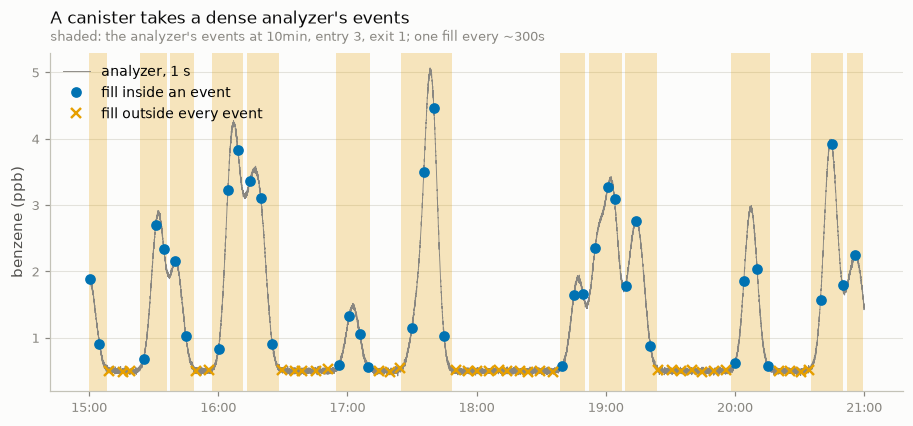

In [23]:
# Figure only: the analyzer's benzene, its events shaded, and the canister's fills on top.
ptr = baselines["ptr"]
t = ptr["time"].values
fig, ax = plt.subplots(figsize=(10, 4.0))
events = triggered["ptr"]["event_benzene"].values[:, 0, 0, 0, 0]
shade_events(ax, stream_cells(ptr, "ptr"), events)
ax.plot(t, ptr["benzene"].values, color=MUTED, lw=0.6, label="analyzer, 1 s")
can = baselines["iwas"]
value = can["benzene_can"].values
ax.plot(
    can["time"].values[in_event], value[in_event], "o", color=C1, ms=6, label="fill inside an event"
)
ax.plot(
    can["time"].values[~in_event],
    value[~in_event],
    "x",
    color=C2,
    ms=6,
    mew=1.6,
    label="fill outside every event",
)
hhmm(ax)
finish(
    ax,
    "A canister takes a dense analyzer's events",
    f"shaded: the analyzer's events at {WINDOW}, entry 3, exit 1; one fill every ~{FILL_EVERY}",
    "benzene (ppb)",
    legend=True,
    loc="upper left",
)
plt.show()

The analyzer finds the plumes, and each shaded interval that holds a fill is
also a canister event, with that fill in it. A plume no fill caught stays in the
analyzer's rows and not the canister's, and the canister's `n_events` counts
only the analyzer's events holding one of its fills. The canister's own
`clean_level`, `peak_z` and chance columns are blank in the catalog, since it
measured no air of its own, and its `trigger_event_id` names the analyzer's row,
so the two stay linked.

**Try it.**
- `FILL_EVERY = "1800s"`: a fill every half hour, so some plumes pass between
  fills; the canister has fewer rows than the analyzer has events.
- `FILL_EVERY = "30s"`: over 700 fills, so the canister's record now has enough
  below its level, and on its own it describes its air (the first print line).
  With the trigger named it still takes the analyzer's events: a trigger is a
  choice, not a fallback.
- `PLUMES_PER_HOUR = 0.5`: few plumes, so most fills are clean and outside
  every event. Most of the analyzer's events are now chance crossings (about
  five an hour at 1 s, §3), short enough that a fill rarely falls in one.

---
## 7. The state and the catalog save, and reload exactly

**The question.** An event state is the input to Phase 7, so it must survive a
save and a reload without losing a bit, and so must the catalog beside it.
`save_events` writes one netCDF file per instrument into the bundle's `events/`
directory, the catalog as Parquet beside them, and the events configuration as
the `events` section of an `analysis.yaml`; `load_events` brings all three back
(`src/tsara/events/bundle.py`). The chain here is §6's, shortened to two hours:
an analyzer that finds its own events and a canister that takes them, so that
both kinds of variable make the round trip.

In [24]:
# ---- PARAMETERS (section 7) --------------------------------------------------
COMPRESSION = 4  # zlib level for the second save, 1 to 9, or None

In [25]:
start_section("§7")
campaign = canister_campaign(duration="2h")
settings = sweep(
    ("2min", "10min"), methods={"iwas.benzene_can": {"method": "constant", "value": 0.0}}
)
baselines = {
    name: baseline_state(campaign.observable(name), instrument=name, baseline=settings)
    for name in ("ptr", "iwas")
}
config = thresholds((3.0, 4.0), (1.0,), triggers={"iwas": "ptr.benzene"})
states = event_states(baselines, config)
catalog = event_catalog(states, baselines)

plain = save_events(states, WORK / "plain", catalog=catalog, events=config)
small = save_events(states, WORK / "small", catalog=catalog, events=config, compression=COMPRESSION)
back = load_events(WORK / "plain")
second = "uncompressed" if COMPRESSION is None else f"at zlib level {COMPRESSION}"
for path in sorted(plain.iterdir()):
    print(
        f"  events/{path.name:18s} {path.stat().st_size / 1e3:8.1f} kB plain, "
        f"{(small / path.name).stat().st_size / 1e3:8.1f} kB {second}"
    )


def identical(a, b):
    """Every variable and coordinate exactly, every attribute exactly, arrays included."""
    if sorted(map(str, a.variables)) != sorted(map(str, b.variables)):
        return False
    for name in a.variables:
        if a[name].dims != b[name].dims or a[name].dtype != b[name].dtype:
            return False
        if not same(a[name].values, b[name].values):
            return False
        for key, value in a[name].attrs.items():
            if name == "time" and key == "bounds":
                continue  # moved into encoding on load, by xarray's CF decoding
            other = b[name].attrs.get(key)
            if isinstance(value, np.ndarray):
                if not np.array_equal(value, other):
                    return False
            elif value != other:
                return False
    return a.attrs == b.attrs


def frames_equal(a, b):
    """Two catalogs with the same columns, types and values, blanks included."""
    try:
        pd.testing.assert_frame_equal(a, b, check_exact=True)
    except AssertionError:
        return False
    return True


check(
    "§7 every reloaded event state is the saved one, every variable and attribute exactly",
    all(identical(states[name], back.states[name]) for name in states),
)
check(
    "§7 the compressed bundle reloads to the same states",
    all(identical(back.states[name], load_events(WORK / "small").states[name]) for name in states),
)
check(
    "§7 the reloaded catalog is the saved one: columns, types and values",
    frames_equal(back.catalog, catalog),
)
check(
    "§7 the catalog built again from the reloaded states is the saved one",
    frames_equal(event_catalog(back.states, baselines), catalog),
)
check("§7 the events configuration comes back beside them", back.events == config)

  events/analysis.yaml           0.3 kB plain,      0.3 kB at zlib level 4
  events/catalog.parquet        19.2 kB plain,     19.2 kB at zlib level 4
  events/iwas.nc                20.5 kB plain,     42.0 kB at zlib level 4
  events/ptr.nc                745.6 kB plain,    176.1 kB at zlib level 4
  ✔ §7 every reloaded event state is the saved one, every variable and attribute exactly
  ✔ §7 the compressed bundle reloads to the same states
  ✔ §7 the reloaded catalog is the saved one: columns, types and values
  ✔ §7 the catalog built again from the reloaded states is the saved one
  ✔ §7 the events configuration comes back beside them


**What to read off the output.** The round trip loses nothing: values, the
cells, the event index at every sweep point, and the attributes that name each
canister variable's trigger. The catalog built again from the reloaded states
equals the saved one, so the catalog is a view of the states and can always be
rebuilt. Compression is a choice at save time and changes only the size: the
analyzer's event index is mostly −1, and its file shrinks about four times,
while the canister's file, a few dozen readings, grows, because compressed
storage is written in chunks that each carry some overhead. Worth it for long
records, not for tiny ones.

**Try it.** `COMPRESSION = None`: the second bundle is as large as the first,
and it still reloads to the same states.

---
## 8. Scoreboard, and what is known to be imperfect

Every check in this notebook, as it ran. Then the limits this phase records
rather than resolves.

In [26]:
held = sum(1 for ok, _ in CHECKS.values() if ok)
print(f"{held} of {len(CHECKS)} checks hold\n")
for claim, (ok, detail) in CHECKS.items():
    print(f"  {'✔' if ok else '✘'} {claim}" + (f"   [{detail}]" if detail else ""))

39 of 39 checks hold

  ✔ §1 the clean level is the half-sample mode, as the paper defines it
  ✔ §1 the clean spread is 1.4826 x the median distance below it
  ✔ §1 z is (enhancement - clean level) / clean spread, reading by reading
  ✔ §1 the clean level lies within one true spread of truly plume-free air   [+0.14 true spreads]
  ✔ §1 the clean spread is within a factor of two of the true one   [1.07]
  ✔ §2 every reading's record is the definition's, reading by reading
  ✔ §2 no record is longer than the maximum length
  ✔ §2 no record spans a gap longer than the record gap
  ✔ §2 a stop shares a record with the drive exactly when it is shorter than the record gap
  ✔ §2 the dropouts are the definition's: steps within a record over 1.5 x its median step   [1 found]
  ✔ §2 with holes under 5s bridged, every reading's event is the definition's
  ✔ §2 with nothing bridged, every reading's event is the definition's
  ✔ §3 every event a single line at entry finds lies inside one event of

### Known to be imperfect, and where each is written down

* **On a plume-dense record the description of clean air can err, and chance
  events multiply.** On §3's three hours, two-thirds plume, plume-free air
  reaches entry nine times as often as the closed form expects at 2 min, and
  never at 10 min. The error is the estimator's own jitter on the record's clean
  air, not the plumes pulling it, and a spread 5 % low lets 1.6 times as many
  chance crossings through at entry 3 (§5). The stage reports these events
  rather than screening them; whether an event is a plume is judged across the
  sweep in Phase 7, where false events of this kind mostly do not recur
  (`METHODS.md` §6.8).
* **The chance column is a reference, not a bound.** It assumes independent
  Gaussian readings: with dips bridged it is an upper bound for noise described
  correctly (§3), and a misdescribed record, or air wandering at the window's
  own scale, crosses more often (§3, §5). Chance events recur at every window
  and quantile, since a noise spike is the same reading at each; only a higher
  entry, or a second gas, thins them (`METHODS.md` §6.8).
* **Wander at the window's own scale is a property of the window.** A background
  rising and falling over about the window stands above a low quantile on one
  side only, as a broad plume does, and the clean spread cannot see it (§1's
  Try it). It is recorded, not flagged: shorter windows follow it.
* **The clean spread is not a measurement uncertainty.** It holds the
  background's wobble at the window's scale as well as the instrument's noise,
  and it is never used as a sigma (`METHODS.md` §2.3, §6.8). What "noise" means
  on a moving platform, where the air changes along the road, is open (§2.5).
* **A record's cuts are arbitrary.** A stream that logs for longer than
  `max_record_length` is cut into equal parts, and an event running across a
  cut is two events, one in each record. Where the platform's speed is named,
  a stop of at least `record_gap` is split off, and shorter stops stay mixed
  with the drive around them (§2; `METHODS.md` §6.8).
* **Scale is not source.** At a short window a broad plume shows as its two
  flanks (§4), and a cluster of short plumes lifts a short window's baseline
  as one long plume would (notebook 05 §2). The tree records which event holds
  which but cannot tell a flank child from a blip child; a baseline that follows
  the slope is recorded as the next step (`METHODS.md` §6.1).
* **A canister's events are its trigger's.** A plume no fill caught is not in
  its rows, and an adopted baseline carries the donor's noise offset into its
  enhancement's values, a question for receptor rows (§6; `METHODS.md` §6.5).